In [32]:
import itertools
import logging
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import random

from modules import background_model, model, ModelDataSet, plotting, ProfileFindingSetup, SequenceRepresentation

logging.basicConfig(level=logging.DEBUG, format='%(asctime)s - %(levelname)s - %(message)s')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

np.set_printoptions(precision=4, suppress=True) # Suppress scientific notation for small numbers for better readability

In [3]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2025-07-18 00:23:40.066657: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-07-18 00:23:40.100706: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-07-18 00:23:40.100859: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


Old vs. New implementation

In [4]:
fasta = Path("/home/ebelm/brain/genomegraph/data/20250408_STREME_benchmark_revisited/diluted_dataset/1.00/primary_sequences/wgEncodeAwgTfbsBroadK562CtcfUniPk.narrowPeak.fasta")
sim_fasta = Path("/home/ebelm/brain/genomegraph/data/20250408_STREME_benchmark_revisited/simulated_dataset/order_2/wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak/1.00/primary_sequences/wgEncodeAwgTfbsSIMULATED.fasta")

In [5]:
genomes = [SequenceRepresentation.Genome([seq]) for seq in SequenceRepresentation.loadFasta_agnostic(fasta)]

In [18]:
len(genomes)

51992

In [19]:
data = ModelDataSet.ModelDataSet(genomes[:1000], ModelDataSet.DataMode.DNA, tile_size=100, tiles_per_X=1, batch_size=1, prefetch=3)

In [20]:
bgmodel = background_model.TrainedQ(data, num_models=1, order=0, rand_seed=SEED)

2025-07-18 00:30:27,756 - DEBUG - [TrainedQ.__init__] >>> setting tf global seed to 42
2025-07-18 00:30:27,778 - DEBUG - [background_model.__init__] >>> Q_logit shape: (1, 4), m_logit shape: (1,)


In [21]:
losses = bgmodel.train(lr=0.01, lr_factor=0.75, lr_patience=10, epochs=50)

2025-07-18 00:30:32,821 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.01
/home/ebelm/brain/genomegraph/.apphub_conda_gpu/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:264: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(
2025-07-18 00:30:33,015 - INFO - [background_model.train] >>> epoch     0 mean loss = 548913.8125, time: 0.19s
2025-07-18 00:30:33,016 - DEBUG - [background_model.train] >>> batch shape: (1, 1, 1000, 2, 100, 4)
2025-07-18 00:30:34,008 - INFO - [background_model.train] >>> epoch    10 mean loss = 544762.0625, time: 1.18s
2025-07-18 00:30:34,009 - DEBUG - [background_model.train] >>> batch shape: (1, 1, 1000, 2, 100, 4)
2025-07-18 00:30:34,922 - INFO - [background_model.train] >>> epoch    20 mean loss = 542573.3125, 

In [22]:
# plot losses
def plot_losses(name: str, losses: list[float]):
    plt.plot(losses, label=f'Losses for Model {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training Loss for {name}')
    plt.legend()
    plt.show()

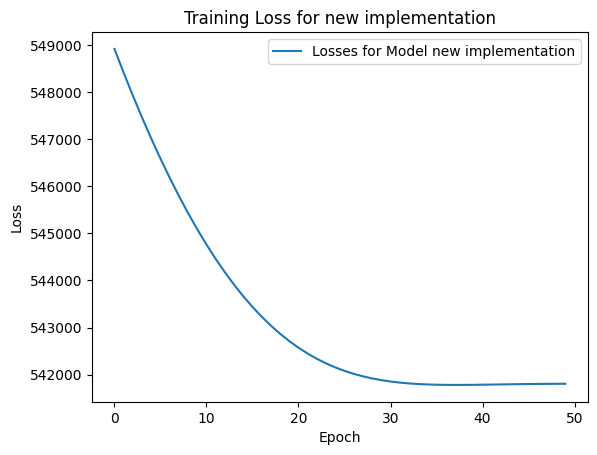

In [23]:
plot_losses("new implementation", losses)

In [24]:
bgmodel.getQ().numpy()[0]

array([0.1822, 0.3185, 0.3187, 0.1805], dtype=float32)

In [25]:
bgmodel.get_avg_Q()

array([0.1822, 0.3185, 0.3187, 0.1805], dtype=float32)

In [26]:
assert (bgmodel.getQ().numpy()[0] == bgmodel.get_avg_Q()).all()

`Q` and `get_avg_Q` are the same for K=1 and order=0, as expected. Thus, a training with new and old implementation should be equivalent

In [27]:
tf.keras.backend.clear_session() # avoid memory cluttering by remains of old models

In [28]:
setup = ProfileFindingSetup.ProfileFindingTrainingSetup(
    data=data,
    U=200, k=12, midK=8, s=0,
    epochs=200, gamma=1.0, l2=0.1, kld=0.0, mellowmax_alpha=1.0,
    match_score_factor=0.7, learning_rate=2.0, lr_patience=5, lr_factor=0.75,
    rho=0.0, sigma=1.0, profile_plateau=10, profile_plateau_dev=150,
    n_best_profiles=5,
    phylo_t=0.0,
    Q_order=0, Q_num_models=1, Q_learning_rate=0.01, Q_lr_patience=10, Q_lr_factor=0.75, Q_epochs=50, Q_rand_seed=SEED,
    Q = bgmodel,
)

In [29]:
tf.config.run_functions_eagerly(True) # needed because otherwise bgmodel.get_avg_Q() will fail because the Tensor.numpy() method is prohibited

In [30]:
legacy_model = model.SpecificProfile(setup, rand_seed=SEED)
legacy_model.legacy_Z = True

2025-07-18 00:30:53,526 - DEBUG - [model.__init__] >>> setting tf global seed to 42


In [31]:
legacy_model.train()

2025-07-18 00:30:53,750 - DEBUG - [model.train.setLR] >>> Setting learning rate to 2.0
2025-07-18 00:30:55,966 - INFO - [model.train] >>> epoch 0 best profile 0 with mean loss 0.3035482168197632
2025-07-18 00:30:55,967 - INFO - [model.train] >>> epoch     0 sum of profile tile losses = 569.0316, max R: 1.712, min R: -13.816, time: 2.10s
2025-07-18 00:31:18,530 - INFO - [model.train] >>> epoch 100 best profile 73 with mean loss -2.333439588546753
2025-07-18 00:31:18,531 - INFO - [model.train] >>> epoch   100 sum of profile tile losses = -423.2186, max R: 1.687, min R: -3.938, time: 24.67s
2025-07-18 00:31:19,790 - INFO - [model.train_reporting.reduceLR] >>> Loss did not decrease for 5 epochs, reducing learning rate from 2.0 to 1.5
2025-07-18 00:31:19,790 - DEBUG - [model.train.setLR] >>> Setting learning rate to 1.5
2025-07-18 00:31:21,796 - INFO - [model.train] >>> epoch 116 best profile 132 with mean loss -2.334751605987549
2025-07-18 00:31:21,797 - INFO - [model.train] >>> cleaning u

(<Figure size 1500x600 with 2 Axes>,
 array([<Axes: title={'center': 'Training loss'}>,
        <Axes: title={'center': 'Training R and S'}>], dtype=object))

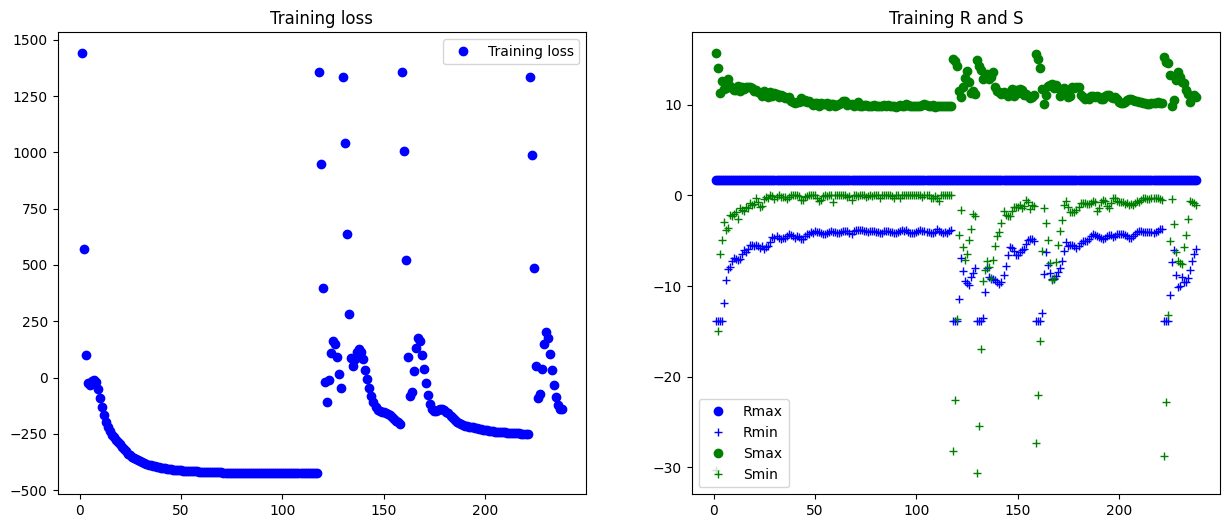

In [33]:
plotting.plotHistory(legacy_model.history)

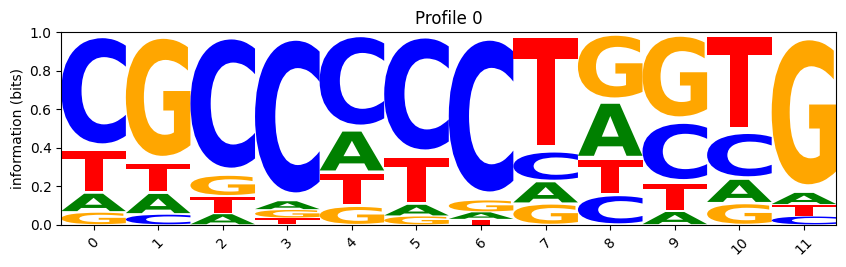

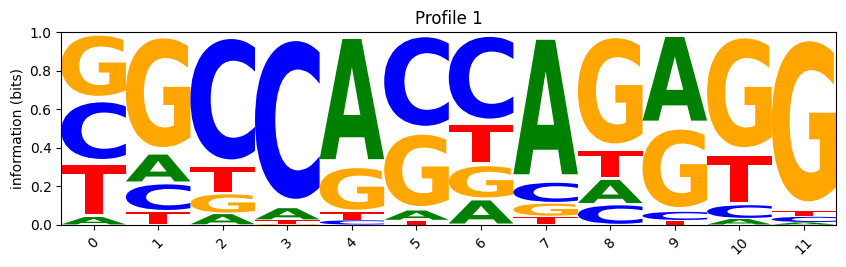

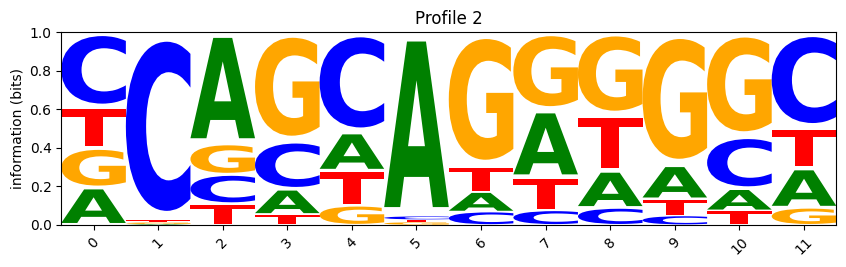

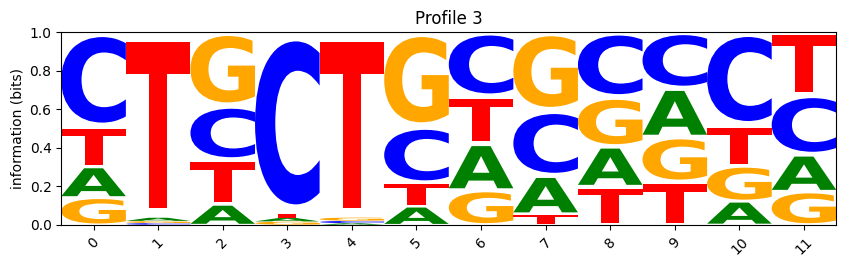

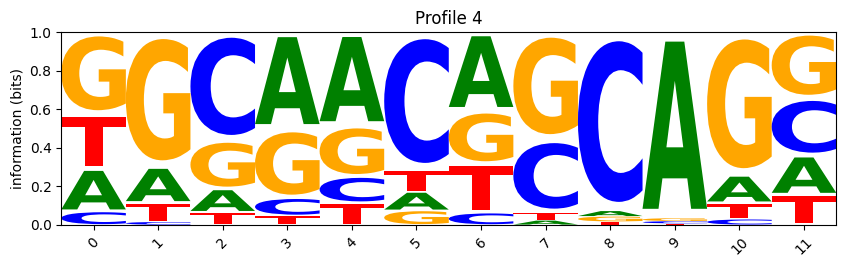

In [35]:
plotting.plotLogo(legacy_model.profile_report.P, data.alphabet)

In [36]:
tf.keras.backend.clear_session() # avoid memory cluttering by remains of old models
new_model = model.SpecificProfile(setup, rand_seed=SEED)
new_model.train()

2025-07-18 00:35:22,424 - DEBUG - [model.__init__] >>> setting tf global seed to 42
/home/ebelm/brain/genomegraph/.apphub_conda_gpu/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:264: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(
2025-07-18 00:35:22,547 - DEBUG - [model.train.setLR] >>> Setting learning rate to 2.0
2025-07-18 00:35:22,933 - INFO - [model.train] >>> epoch 0 best profile 54 with mean loss 0.3995800018310547
2025-07-18 00:35:22,934 - INFO - [model.train] >>> epoch     0 sum of profile tile losses = 544.8810, max R: 0.000, min R: 0.000, time: 0.27s
2025-07-18 00:35:24,649 - INFO - [model.train_reporting.reduceLR] >>> Loss did not decrease for 5 epochs, reducing learning rate from 2.0 to 1.5
2025-07-18 00:35:24,649 - DEBUG - [model.t

(<Figure size 1500x600 with 2 Axes>,
 array([<Axes: title={'center': 'Training loss'}>,
        <Axes: title={'center': 'Training R and S'}>], dtype=object))

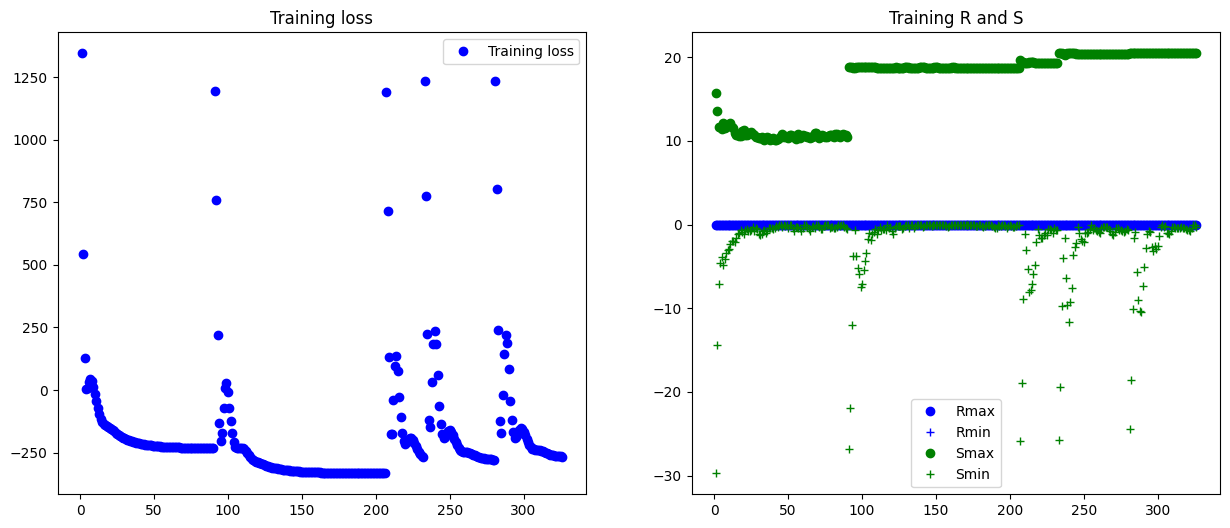

In [37]:
plotting.plotHistory(new_model.history)

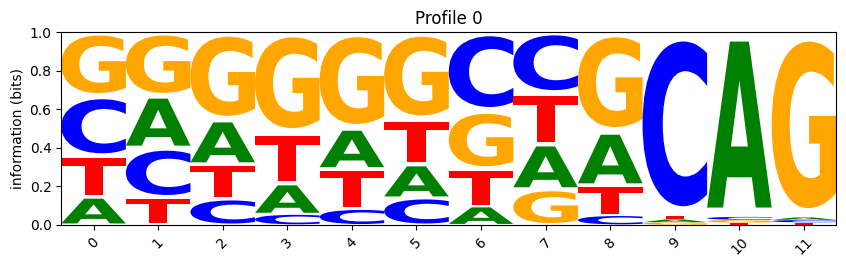

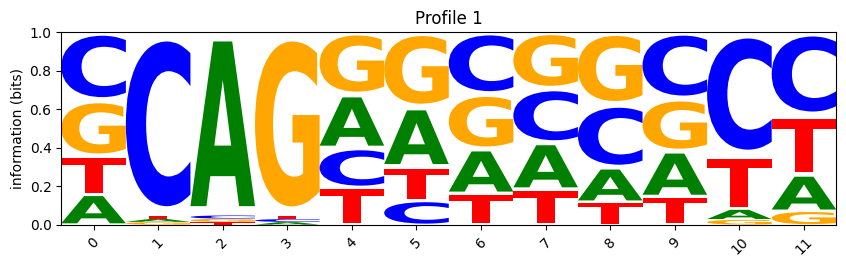

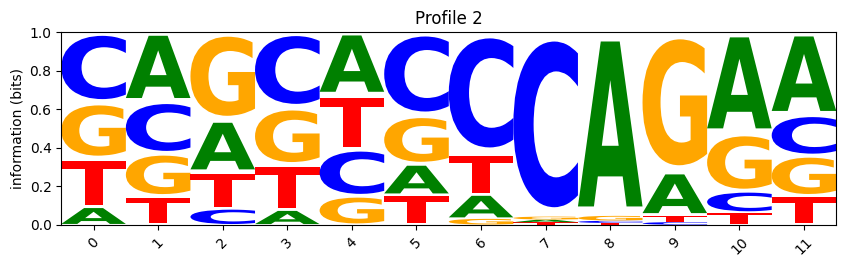

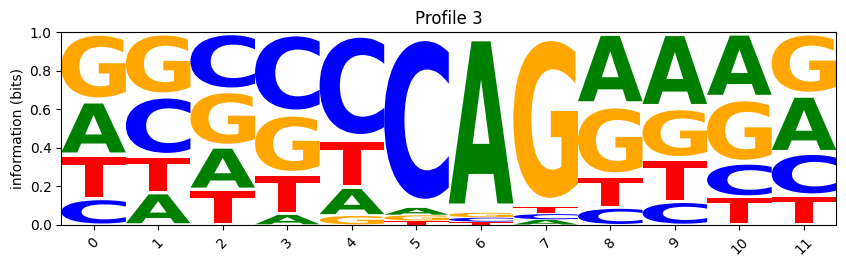

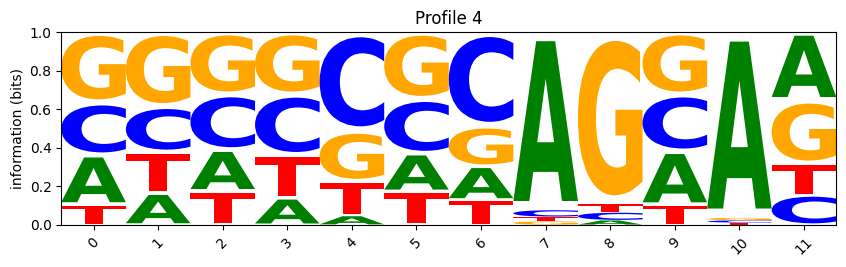

In [38]:
plotting.plotLogo(new_model.profile_report.P, data.alphabet)

---

In [2]:
def from_one_hot(X, k):
    """Convert one-hot encoded tensor to string representation."""
    import itertools
    alphabet = [''.join(p) for p in itertools.product([c for c in 'ACGT'], repeat=k)]
    assert X.shape[-1] == 4**k, "Last dimension must match 4^k for k-mer encoding"
    assert len(X.shape) == 6, "Input tensor must be 6D: (batch_size, tiles_per_X, N, f, tile_size, alphabet_size)"
    for b in range(X.shape[0]):
        for t in range(X.shape[1]):
            for n in range(X.shape[2]):
                for f in range(X.shape[3]):
                    oh = X[b, t, n, f, :, :]
                    idcs = [np.argmax(oh[j,:]) if np.max(oh[j,:]) != 0 else -1 \
                            for j in range(oh.shape[0])]
                    seq = ' '.join([ alphabet[i] if i != -1 else 'N' for i in idcs ])
                    print(f"Batch {b}, Tile {t}, Sequence {n}, Frame {f}: {seq}")
    #return ''.join(['ACGT'[np.argmax(x)] for x in X])

In [3]:
# quick test of k-mer dataset
raw_data = [
    'ACGT',
    'AACCGGTT',
    'TAACGTAG'
]
data = ModelDataSet.ModelDataSet(
    [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=s)]) \
                                   for i, s in enumerate(raw_data)],
    ModelDataSet.DataMode.DNA,
    tile_size=8,
    tiles_per_X=1,
    batch_size=1,
    prefetch=1,
)

ds = data.getDataset(k=1)
for X, _ in ds:
    assert X.shape == (1,1,3,2,8,4)  # (batch_size, tiles_per_X, len(raw_data), frames, tile_size, alphabet_size)
    print(X.shape)
    print(X[0, 0, :, 0, :, :].numpy())  # Print the first tile, first frame
    from_one_hot(X.numpy(), 1)
    break

(1, 1, 3, 2, 8, 4)
[[[1. 0. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]
  [0. 0. 0. 1.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[1. 0. 0. 0.]
  [1. 0. 0. 0.]
  [0. 1. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]
  [0. 0. 1. 0.]
  [0. 0. 0. 1.]
  [0. 0. 0. 1.]]

 [[0. 0. 0. 1.]
  [1. 0. 0. 0.]
  [1. 0. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]
  [0. 0. 0. 1.]
  [1. 0. 0. 0.]
  [0. 0. 1. 0.]]]
Batch 0, Tile 0, Sequence 0, Frame 0: A C G T N N N N
Batch 0, Tile 0, Sequence 0, Frame 1: A C G T N N N N
Batch 0, Tile 0, Sequence 1, Frame 0: A A C C G G T T
Batch 0, Tile 0, Sequence 1, Frame 1: A A C C G G T T
Batch 0, Tile 0, Sequence 2, Frame 0: T A A C G T A G
Batch 0, Tile 0, Sequence 2, Frame 1: C T A C G T T A


In [4]:
ds = data.getDataset(k=2)
for X, _ in ds:
    assert X.shape == (1,1,3,2,7,16), f"Expected shape {(1,1,2,2,7,16)}, got {X.shape}"  # (batch_size, tiles_per_X, len(raw_data), frames, tile_size, alphabet_size)
    print(X.shape)
    print(X[0, 0, :, 0, :, :].numpy())  # Print the first tile, first frame
    from_one_hot(X, 2)  # Convert to string representation
    break

(1, 1, 3, 2, 7, 16)
[[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

 [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]

 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0

In [5]:
ds = data.getDataset(k=3)
for X, _ in ds:
    assert X.shape == (1,1,3,2,6,64)  # (batch_size, tiles_per_X, len(raw_data), frames, tile_size, alphabet_size)
    print(X.shape)
    print(X[0, 0, :, 0, :, :].numpy())  # Print the first tile, first frame
    from_one_hot(X.numpy(), 3)  # Convert to string representation
    break

(1, 1, 3, 2, 6, 64)
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 1. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 1. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]
Batch 0, Tile 0, Sequence 0, Frame 0: ACG CGT N N N N
Batch 0, Tile 0, Sequence 0, Frame 1: ACG CGT N N N N
Batch 0, Tile 0, Sequence 1, Frame 0: AAC ACC CCG CGG GGT GTT
Batch 0, Tile 0, Sequence 1, Frame 1: AAC ACC CCG CGG GGT GTT
Batch 0, Tile 0, Sequence 2, Frame 0: TAA AAC ACG CGT GTA TAG
Batch 0, Tile 0, Sequence 2, Frame 1: CTA TAC ACG CGT GTT TTA


---

In [2]:
N = 1000
seqlen = 100
tile_size = 100
batch_size = 1# 32
K = 1

In [3]:
def generate_data(model: np.ndarray, N: int, seqlen: int, tile_size: int, batch_size: int, alphabet: str = "ACGT") -> ModelDataSet.ModelDataSet:
    assert model.shape == (4,), "Model must be a 4 element vector for ACGT alphabet and zeroth order Markov model."
    # Generate random sequences based on the provided model
    raw_data = []
    for _ in range(N):
        seq = random.choices(alphabet, weights=model, k=seqlen)
        # Join the sequence into a string
        seq_str = ''.join(seq)
        # Append the sequence to the data list
        raw_data.append(seq_str)
    # Create a ModelDataSet object with the generated sequences
    genomes = [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=seq)]) \
               for i, seq in enumerate(raw_data)]
    data = ModelDataSet.ModelDataSet(genomes, ModelDataSet.DataMode.DNA,
                                     tile_size=tile_size, tiles_per_X=1, batch_size=batch_size, prefetch=1)
    assert ''.join(data.alphabet) == "ACGT", \
        f"[generate_data] Alphabet must be ACGT for this model, not {data.alphabet}."
    logging.debug(f"[generate_data] Steps per epoch: {data.getStepsPerEpoch()}.")

    # count the relative frequencies of the nucleotides in the generated sequences for verification
    counts = np.zeros(len(alphabet), dtype=int)
    for seq in raw_data:
        for c in seq:
            assert c in alphabet, \
                f"[generate_data] Sequence contains character {c} not in alphabet {alphabet}." # should not happen
            ci = alphabet.index(c)
            counts[ci] += 1

    # Calculate the relative frequencies
    relative_frequencies = counts / np.sum(counts)
    logging.info(f"[generate_data] Relative frequencies of nucleotides in generated data: {relative_frequencies}")
            
    return data, relative_frequencies

In [4]:
ground_truth_1 = np.array([0.25, 0.25, 0.25, 0.25])  # Uniform distribution
ground_truth_2 = np.array([0.1, 0.2, 0.3, 0.4])      # Non-uniform distribution
ground_truth_3 = np.array([0.1, 0.4, 0.4, 0.1])      # Another non-uniform distribution

In [ ]:
def single_model_test(ground_truth: np.ndarray, name: str, lr: float = 0.1, epochs: int = 50,
                      N: int = N, seqlen: int = seqlen, tile_size: int = tile_size, batch_size: int = batch_size, 
                      K: int = 1, perfect_initialization: bool = False):
    """ 
    K: since there is only one ground truth, by default learn only one model. However, it might make sense to learn
       two models for unbalanced ground truths, as the data contains both the fwd and rc sequences which will have
       opposing distributions. In this case, try setting K to 2.
    perfect_initialization: If True, initializes the model with the relative nt frequencies of the data. """
    logging.info(f"Testing model {name} with parameters: {ground_truth} " \
                 + f"and hyperparameters {lr=}, {epochs=}, {N=}, {seqlen=}, {tile_size=}, {batch_size=}, {K=}")
    
    data, relative_frequencies = generate_data(ground_truth, N, seqlen, tile_size, batch_size)
    model = background_model.TrainedQ(data, num_models=K, order=0, rand_seed=SEED)

    if perfect_initialization:
        assert K == 1, f"[single_model_test] perfect_initialization is not supported with {K=} != 1"
        # Initialize the model with the relative frequencies of the nucleotides in the generated data
        model.Q_logit.assign(np.expand_dims(np.log(relative_frequencies), 0))
        model.m_logit.assign([1.0])  # Initialize m to 1.0 for simplicity

    # get initial model parameters
    Q_init_raw = model.Q_logit.numpy()
    Q_init = model.getQ().numpy()
    m_init_raw = model.m_logit.numpy()
    m_init = model.getM().numpy()
    
    # Fit the background model
    losses = model.train(lr, epochs)

    # plot losses
    plt.plot(losses, label=f'Losses for Model {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training Loss for {name}')
    plt.legend()
    plt.show()

    # Get the trained model parameters
    Q_trained_raw = model.Q_logit.numpy()
    Q_trained = model.getQ().numpy()
    m_trained_raw = model.m_logit.numpy()
    m_trained = model.getM().numpy()

    logging.info(f"Initial Q (logit/softmax):\n{Q_init_raw}\n\n{Q_init},\n\nTrained Q (logit/softmax):\n{Q_trained_raw}\n\n{Q_trained}")
    logging.info(f"Initial m (logit/softmax):\n{m_init_raw}\n\n{m_init},\n\nTrained m (logit/softmax):\n{m_trained_raw}\n\n{m_trained}")
    logging.info(f"Relative frequencies of nucleotides in generated data:\n{relative_frequencies}")

2025-06-26 18:23:21,675 - INFO - Testing model Uniform Distribution with parameters: [0.25 0.25 0.25 0.25] and hyperparameters lr=0.1, epochs=50, N=1000, seqlen=100, tile_size=100, batch_size=1, K=1


2025-06-26 18:23:22,065 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-26 18:23:22,091 - INFO - [generate_data] Relative frequencies of nucleotides in generated data: [0.2505 0.2488 0.2501 0.2506]
2025-06-26 18:23:22,120 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-26 18:23:22,145 - DEBUG - [background_model.__init__] >>> Q_logit shape: (1, 4), m_logit shape: (1,)
2025-06-26 18:23:22,156 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.1
2025-06-26 18:23:23.306215: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-26 18:23:23,309 - INFO - [background_model.train] >>> epoch     0 mean loss = 277697.0625, time: 1.15s
2025-06-26 18:23:23,310 - DEBUG - [background_model.train] >>> batch shape: (1, 1, 1000, 2, 100, 4)
2025-06-26 18:23:23.743935: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence

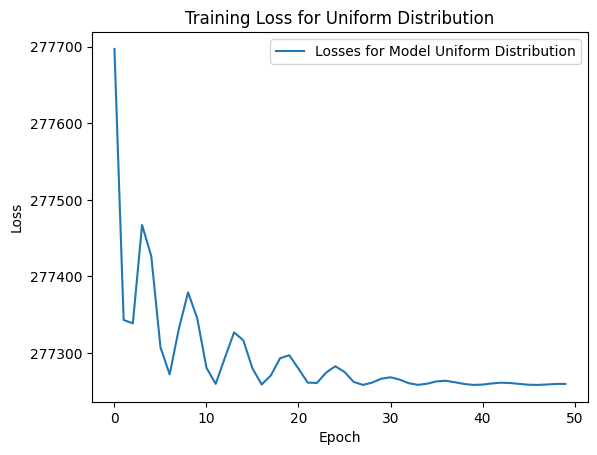

2025-06-26 18:23:45,616 - INFO - Initial Q (logit/softmax):
[[ 0.0329 -0.0118 -0.0294 -0.0071]]

[[0.2593 0.248  0.2436 0.2491]],

Trained Q (logit/softmax):
[[0.0177 0.0079 0.0032 0.0109]]

[[0.252  0.2495 0.2483 0.2502]]
2025-06-26 18:23:45,617 - INFO - Initial m (logit/softmax):
[0.0376]

[1.],

Trained m (logit/softmax):
[0.0376]

[1.]
2025-06-26 18:23:45,618 - INFO - Relative frequencies of nucleotides in generated data:
[0.2505 0.2488 0.2501 0.2506]


In [6]:
single_model_test(ground_truth_1, "Uniform Distribution")

2025-06-26 18:25:15,870 - INFO - Testing model Uniform Distribution perfect init with parameters: [0.25 0.25 0.25 0.25] and hyperparameters lr=0.01, epochs=50, N=1000, seqlen=100, tile_size=100, batch_size=1, K=1
2025-06-26 18:25:16,246 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-26 18:25:16,271 - INFO - [generate_data] Relative frequencies of nucleotides in generated data: [0.2482 0.2501 0.2533 0.2484]
2025-06-26 18:25:16,276 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-26 18:25:16,285 - DEBUG - [background_model.__init__] >>> Q_logit shape: (1, 4), m_logit shape: (1,)
2025-06-26 18:25:16,295 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.01
2025-06-26 18:25:16.909955: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-26 18:25:16,913 - INFO - [background_model.train] >>> epoch     0 mean loss = 277259.4375, time: 0.62s
2025-06-26 18:25:16,913 - DEBUG - [bac

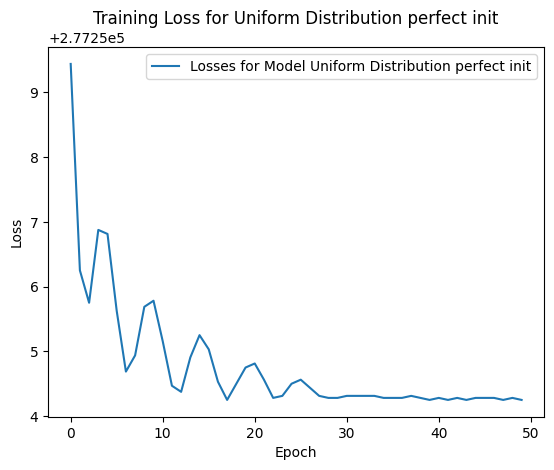

2025-06-26 18:25:36,943 - INFO - Initial Q (logit/softmax):
[[-1.3936 -1.3859 -1.3732 -1.3926]]

[[0.2482 0.2501 0.2533 0.2484]],

Trained Q (logit/softmax):
[[-1.3935 -1.3801 -1.38   -1.3923]]

[[0.2482 0.2516 0.2516 0.2486]]
2025-06-26 18:25:36,944 - INFO - Initial m (logit/softmax):
[1.]

[1.],

Trained m (logit/softmax):
[1.]

[1.]
2025-06-26 18:25:36,945 - INFO - Relative frequencies of nucleotides in generated data:
[0.2482 0.2501 0.2533 0.2484]


In [9]:
single_model_test(ground_truth_1, "Uniform Distribution perfect init", lr=0.01, perfect_initialization=True)

2025-06-26 18:27:09,777 - INFO - Testing model Non-Uniform Distribution 1 with parameters: [0.1 0.2 0.3 0.4] and hyperparameters lr=5, epochs=50, N=1000, seqlen=100, tile_size=100, batch_size=1, K=1
2025-06-26 18:27:10,160 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-26 18:27:10,188 - INFO - [generate_data] Relative frequencies of nucleotides in generated data: [0.1001 0.2004 0.297  0.4025]
2025-06-26 18:27:10,193 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-26 18:27:10,206 - DEBUG - [background_model.__init__] >>> Q_logit shape: (1, 4), m_logit shape: (1,)
2025-06-26 18:27:10,214 - DEBUG - [model.train.setLR] >>> Setting learning rate to 5
2025-06-26 18:27:11.077315: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-26 18:27:11,081 - INFO - [background_model.train] >>> epoch     0 mean loss = 719863.1250, time: 0.86s
2025-06-26 18:27:11,082 - DEBUG - [background_model.tra

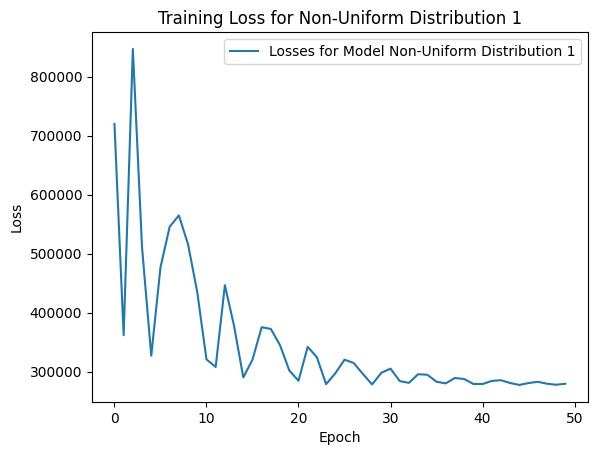

2025-06-26 18:27:31,288 - INFO - Initial Q (logit/softmax):
[[ 0.0329 -0.0118 -0.0294 -0.0071]]

[[0.2593 0.248  0.2436 0.2491]],

Trained Q (logit/softmax):
[[0.0755 0.4382 0.3776 0.4176]]

[[0.1924 0.2765 0.2602 0.2709]]
2025-06-26 18:27:31,289 - INFO - Initial m (logit/softmax):
[0.0376]

[1.],

Trained m (logit/softmax):
[0.0376]

[1.]
2025-06-26 18:27:31,290 - INFO - Relative frequencies of nucleotides in generated data:
[0.1001 0.2004 0.297  0.4025]


In [10]:
single_model_test(ground_truth_2, "Non-Uniform Distribution 1", lr=5)

2025-06-26 18:27:31,311 - INFO - Testing model Non-Uniform Distribution 1 perfect init with parameters: [0.1 0.2 0.3 0.4] and hyperparameters lr=0.01, epochs=50, N=1000, seqlen=100, tile_size=100, batch_size=1, K=1
2025-06-26 18:27:31,692 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-26 18:27:31,719 - INFO - [generate_data] Relative frequencies of nucleotides in generated data: [0.0998 0.1983 0.3014 0.4006]
2025-06-26 18:27:31,724 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-26 18:27:31,736 - DEBUG - [background_model.__init__] >>> Q_logit shape: (1, 4), m_logit shape: (1,)
2025-06-26 18:27:31,746 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.01
2025-06-26 18:27:32.376775: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-26 18:27:32,379 - INFO - [background_model.train] >>> epoch     0 mean loss = 301064.5625, time: 0.63s
2025-06-26 18:27:32,380 - DEBUG - [b

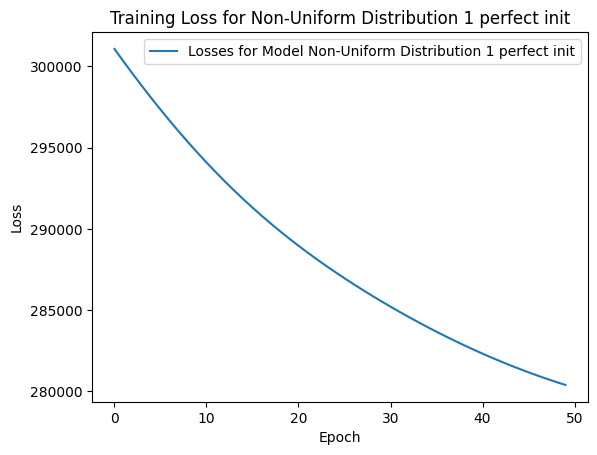

2025-06-26 18:27:52,612 - INFO - Initial Q (logit/softmax):
[[-2.3046 -1.6181 -1.1994 -0.9149]]

[[0.0998 0.1983 0.3014 0.4006]],

Trained Q (logit/softmax):
[[-1.8477 -1.5099 -1.5255 -1.3498]]

[[0.1843 0.2583 0.2543 0.3031]]
2025-06-26 18:27:52,613 - INFO - Initial m (logit/softmax):
[1.]

[1.],

Trained m (logit/softmax):
[1.]

[1.]
2025-06-26 18:27:52,613 - INFO - Relative frequencies of nucleotides in generated data:
[0.0998 0.1983 0.3014 0.4006]


In [11]:
single_model_test(ground_truth_2, "Non-Uniform Distribution 1 perfect init", lr=0.01, perfect_initialization=True)

Vermutung: Verteilung `[A: 0.1, C: 0.2, G: 0.3, T: 0.4]` wird nicht gelernt, da das in den RC-Sequenzen zu 
`[A: 0.4, C: 0.3, G: 0.2, T: 0.1]` führt. Bei asymmetrischen Verteilungen könnten aber zwei zu lernende Modelle mit 
gleichen Gewichten funktionieren

2025-06-26 18:27:52,625 - INFO - Testing model Non-Uniform Distribution 2, v2 with parameters: [0.1 0.2 0.3 0.4] and hyperparameters lr=0.1, epochs=50, N=1000, seqlen=100, tile_size=100, batch_size=1, K=2
2025-06-26 18:27:53,010 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-26 18:27:53,036 - INFO - [generate_data] Relative frequencies of nucleotides in generated data: [0.099  0.2021 0.3004 0.3985]
2025-06-26 18:27:53,041 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-26 18:27:53,053 - DEBUG - [background_model.__init__] >>> Q_logit shape: (2, 4), m_logit shape: (2,)
2025-06-26 18:27:53,062 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.1
2025-06-26 18:27:53.725383: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-26 18:27:53,729 - INFO - [background_model.train] >>> epoch     0 mean loss = 269246.3750, time: 0.67s
2025-06-26 18:27:53,729 - DEBUG - [background_m

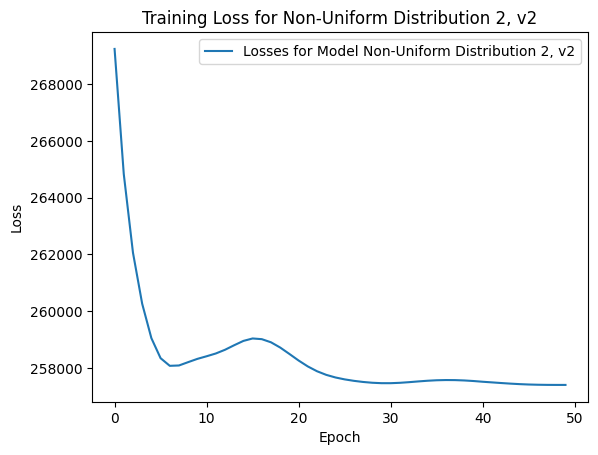

2025-06-26 18:28:14,350 - INFO - Initial Q (logit/softmax):
[[ 0.0329 -0.0118 -0.0294 -0.0071]
 [-0.0933  0.0369  0.048   0.0745]]

[[0.2593 0.248  0.2436 0.2491]
 [0.2235 0.2546 0.2575 0.2644]],

Trained Q (logit/softmax):
[[ 0.6679  0.3825 -0.0298 -0.7125]
 [-0.7726 -0.0536  0.3678  0.6486]]

[[0.3999 0.3006 0.199  0.1006]
 [0.0969 0.1988 0.303  0.4013]]
2025-06-26 18:28:14,351 - INFO - Initial m (logit/softmax):
[ 0.0376 -0.0031]

[0.5102 0.4898],

Trained m (logit/softmax):
[0.0203 0.0142]

[0.5015 0.4985]
2025-06-26 18:28:14,352 - INFO - Relative frequencies of nucleotides in generated data:
[0.099  0.2021 0.3004 0.3985]


In [12]:
single_model_test(ground_truth_2, "Non-Uniform Distribution 2, v2", lr=0.1, epochs=50, N=1000, seqlen=100, batch_size=1, K=2)

2025-06-26 18:28:14,363 - INFO - Testing model Non-Uniform Distribution 2 with parameters: [0.1 0.4 0.4 0.1] and hyperparameters lr=0.1, epochs=50, N=1000, seqlen=100, tile_size=100, batch_size=1, K=1


2025-06-26 18:28:14,773 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-26 18:28:14,800 - INFO - [generate_data] Relative frequencies of nucleotides in generated data: [0.1004 0.4028 0.3987 0.0981]
2025-06-26 18:28:14,807 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-26 18:28:14,817 - DEBUG - [background_model.__init__] >>> Q_logit shape: (1, 4), m_logit shape: (1,)
2025-06-26 18:28:14,828 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.1
2025-06-26 18:28:15.707992: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-26 18:28:15,711 - INFO - [background_model.train] >>> epoch     0 mean loss = 267934.2812, time: 0.88s
2025-06-26 18:28:15,712 - DEBUG - [background_model.train] >>> batch shape: (1, 1, 1000, 2, 100, 4)
2025-06-26 18:28:16.106059: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence

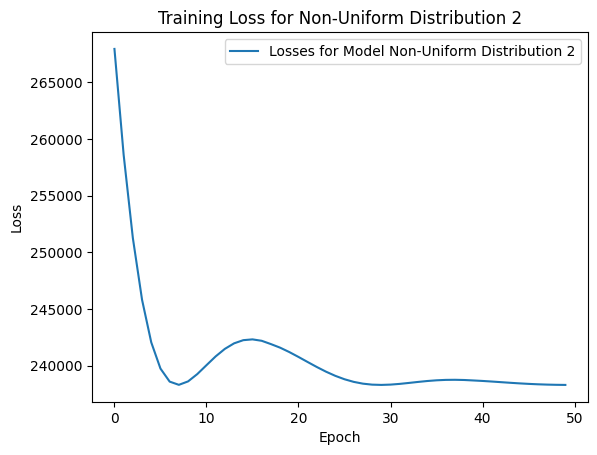

2025-06-26 18:28:36,326 - INFO - Initial Q (logit/softmax):
[[ 0.0329 -0.0118 -0.0294 -0.0071]]

[[0.2593 0.248  0.2436 0.2491]],

Trained Q (logit/softmax):
[[-0.69    0.6879  0.6873 -0.6998]]

[[0.1008 0.3998 0.3996 0.0998]]
2025-06-26 18:28:36,327 - INFO - Initial m (logit/softmax):
[0.0376]

[1.],

Trained m (logit/softmax):
[0.0376]

[1.]
2025-06-26 18:28:36,329 - INFO - Relative frequencies of nucleotides in generated data:
[0.1004 0.4028 0.3987 0.0981]


In [13]:
single_model_test(ground_truth_3, "Non-Uniform Distribution 2")

2025-06-26 18:28:36,341 - INFO - Testing model Non-Uniform Distribution 2 perfect init with parameters: [0.1 0.4 0.4 0.1] and hyperparameters lr=0.01, epochs=50, N=1000, seqlen=100, tile_size=100, batch_size=1, K=1


2025-06-26 18:28:36,760 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-26 18:28:36,786 - INFO - [generate_data] Relative frequencies of nucleotides in generated data: [0.098  0.4    0.4035 0.0985]
2025-06-26 18:28:36,793 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-26 18:28:36,804 - DEBUG - [background_model.__init__] >>> Q_logit shape: (1, 4), m_logit shape: (1,)
2025-06-26 18:28:36,816 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.01
2025-06-26 18:28:37.472451: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-26 18:28:37,476 - INFO - [background_model.train] >>> epoch     0 mean loss = 237732.6562, time: 0.66s
2025-06-26 18:28:37,477 - DEBUG - [background_model.train] >>> batch shape: (1, 1, 1000, 2, 100, 4)
2025-06-26 18:28:37.865455: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequenc

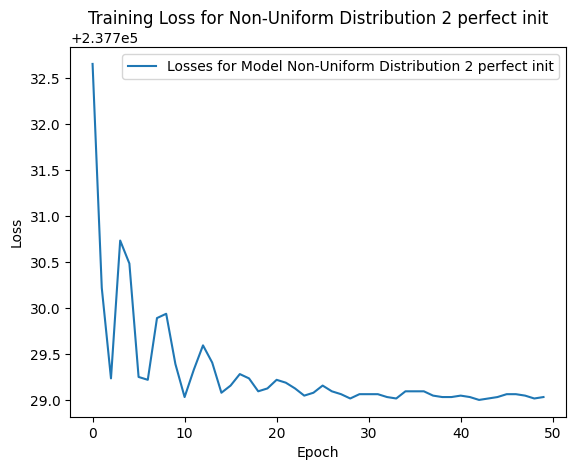

2025-06-26 18:28:58,017 - INFO - Initial Q (logit/softmax):
[[-2.3229 -0.9163 -0.9076 -2.3177]]

[[0.098  0.4    0.4035 0.0985]],

Trained Q (logit/softmax):
[[-2.3194 -0.9123 -0.9122 -2.3195]]

[[0.0983 0.4017 0.4017 0.0983]]
2025-06-26 18:28:58,018 - INFO - Initial m (logit/softmax):
[1.]

[1.],

Trained m (logit/softmax):
[1.]

[1.]
2025-06-26 18:28:58,018 - INFO - Relative frequencies of nucleotides in generated data:
[0.098  0.4    0.4035 0.0985]


In [14]:
single_model_test(ground_truth_3, "Non-Uniform Distribution 2 perfect init", lr=0.01, perfect_initialization=True)

---

In [15]:
def generate_mixed_data(models: list[np.ndarray], weights: list[float], N: int, seqlen: int, tile_size: int, 
                        batch_size: int, alphabet: str = "ACGT") -> ModelDataSet.ModelDataSet:
    assert len(models) == len(weights), "Number of models must match number of weights."
    assert np.isclose(np.sum(weights), 1.0), "Weights must sum to 1."
    for model in models:
        assert model.shape == (4,), "Model must be a 4 element vector for ACGT alphabet and zeroth order Markov model."
    # Generate random sequences based on the provided model
    raw_data = []
    chosen_models = []
    for _ in range(N):
        # Choose a model based on the weights
        mi = random.choices(range(len(models)), weights=weights, k=1)[0]
        model = models[mi]
        # Generate a sequence using the chosen model
        seq = random.choices(alphabet, weights=model, k=seqlen)
        # Join the sequence into a string
        seq_str = ''.join(seq)
        # Append the sequence to the data list
        raw_data.append(seq_str)
        chosen_models.append(mi)

    # Create a ModelDataSet object with the generated sequences
    genomes = [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=seq,
                                                                              source=f"model {chosen_models[i]}")]) \
               for i, seq in enumerate(raw_data)]
    data = ModelDataSet.ModelDataSet(genomes, ModelDataSet.DataMode.DNA,
                                     tile_size=tile_size, tiles_per_X=1, batch_size=batch_size, prefetch=1)
    assert ''.join(data.alphabet) == "ACGT", \
        f"[generate_data] Alphabet must be ACGT for this model, not {data.alphabet}."
    logging.debug(f"[generate_data] Steps per epoch: {data.getStepsPerEpoch()}.")

    # count the relative frequencies of the nucleotides in the generated sequences for verification
    counts = [np.zeros(len(alphabet), dtype=int) for _ in range(len(models))]
    for i, seq in enumerate(raw_data):
        mi = chosen_models[i]
        for c in seq:
            assert c in alphabet, \
                f"[generate_data] Sequence contains character {c} not in alphabet {alphabet}." # should not happen
            ci = alphabet.index(c)
            counts[mi][ci] += 1

    # Calculate the relative frequencies
    relative_frequencies = [counts[mi] / np.sum(counts[mi]) for mi in range(len(models))]
    logging.info(f"[generate_data] Relative frequencies of nucleotides in generated data:\n{relative_frequencies}")
            
    return data, relative_frequencies

In [ ]:
def multi_model_test(ground_truths: list[np.ndarray], weights: list[float], name: str, 
                     lr: float = 0.1, epochs: int = 50, N: int = N, seqlen: int = seqlen, tile_size: int = tile_size, 
                     batch_size: int = batch_size, K: int = None, perfect_initialization: bool = False):
    """ perfect_initialization: If True, initializes the model with the relative nt frequencies of the data. """
    assert len(ground_truths) >= 1, "At least one ground truth model is required for multi-model testing."
    assert len(ground_truths) == len(weights), "Number of ground truth models must match number of weights."
    if K is None:
        K = len(ground_truths)
    else:
        assert K >= 1, f"Need to train at least one model, got {K=}"
    logging.info(f"Testing model {name} with parameters: {ground_truths} " \
                 + f"and hyperparameters {lr=}, {epochs=}, {N=}, {seqlen=}, {tile_size=}, {batch_size=}, {K=}")
    
    data, relative_frequencies = generate_mixed_data(ground_truths, weights, N, seqlen, tile_size, batch_size)
    model = background_model.TrainedQ(data, num_models=K, order=0, rand_seed=SEED)

    if perfect_initialization:
        # Initialize the model with the relative frequencies of the nucleotides in the generated data
        model.Q_logit.assign(np.log(np.array(relative_frequencies)))
        model.m_logit.assign(np.log(weights))  # Initialize m to 1.0 for simplicity

    # get initial model parameters
    Q_init_raw = model.Q_logit.numpy()
    Q_init = model.getQ().numpy()
    m_init_raw = model.m_logit.numpy()
    m_init = model.getM().numpy()
    
    # Fit the background model
    losses = model.train(lr, epochs)

    # plot losses
    plt.plot(losses, label=f'Losses for Model {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training Loss for {name}')
    plt.legend()
    plt.show()

    # Get the trained model parameters
    Q_trained_raw = model.Q_logit.numpy()
    Q_trained = model.getQ().numpy()
    m_trained_raw = model.m_logit.numpy()
    m_trained = model.getM().numpy()

    logging.info(f"Initial Q (logit/softmax):\n{Q_init_raw}\n\n{Q_init}")
    logging.info(f"Initial m (logit/softmax):\n{m_init_raw}\n\n{m_init}")
    logging.info(f"Trained Q (logit/softmax):\n{Q_trained_raw}\n\n{Q_trained}")
    logging.info(f"Trained m (logit/softmax):\n{m_trained_raw}\n\n{m_trained}")
    logging.info(f"Relative frequencies of nucleotides in generated data:\n{relative_frequencies}\n\nwith weights:\n{weights}")

2025-06-26 18:29:57,271 - INFO - Testing model Mixed Model 1 with parameters: [array([0.25, 0.25, 0.25, 0.25]), array([0.1, 0.2, 0.3, 0.4]), array([0.1, 0.4, 0.4, 0.1])] and hyperparameters lr=0.1, epochs=75, N=1000, seqlen=100, tile_size=100, batch_size=1, K=3
2025-06-26 18:29:57,699 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-26 18:29:57,725 - INFO - [generate_data] Relative frequencies of nucleotides in generated data:
[array([0.251 , 0.2457, 0.2562, 0.247 ]), array([0.103 , 0.2024, 0.3007, 0.3939]), array([0.0998, 0.4002, 0.401 , 0.099 ])]
2025-06-26 18:29:57,732 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-26 18:29:57,743 - DEBUG - [background_model.__init__] >>> Q_logit shape: (3, 4), m_logit shape: (3,)
2025-06-26 18:29:57,755 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.1
2025-06-26 18:29:58.432911: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06

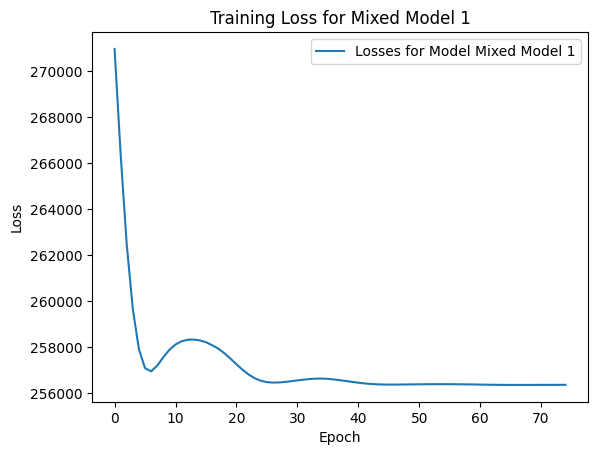

2025-06-26 18:30:29,066 - INFO - Initial Q (logit/softmax):
[[ 0.0329 -0.0118 -0.0294 -0.0071]
 [-0.0933  0.0369  0.048   0.0745]
 [-0.0547 -0.0554 -0.0379  0.0445]]

[[0.2593 0.248  0.2436 0.2491]
 [0.2235 0.2546 0.2575 0.2644]
 [0.2427 0.2425 0.2468 0.268 ]]
2025-06-26 18:30:29,067 - INFO - Initial m (logit/softmax):
[ 0.0376 -0.0031  0.0862]

[0.3322 0.319  0.3488]
2025-06-26 18:30:29,068 - INFO - Trained Q (logit/softmax):
[[ 0.4328  0.237  -0.0133 -0.3619]
 [-0.6645  0.706   0.7057 -0.6695]
 [-0.5063 -0.1524  0.1041  0.2966]]

[[0.3432 0.2822 0.2197 0.155 ]
 [0.1013 0.399  0.3989 0.1008]
 [0.1539 0.2192 0.2833 0.3435]]
2025-06-26 18:30:29,069 - INFO - Trained m (logit/softmax):
[-0.251   0.345  -0.2991]

[0.2654 0.4817 0.2529]
2025-06-26 18:30:29,070 - INFO - Relative frequencies of nucleotides in generated data:
[array([0.251 , 0.2457, 0.2562, 0.247 ]), array([0.103 , 0.2024, 0.3007, 0.3939]), array([0.0998, 0.4002, 0.401 , 0.099 ])]

with weights:
[0.2, 0.3, 0.5]


In [17]:
multi_model_test([ground_truth_1, ground_truth_2, ground_truth_3], [0.2, 0.3, 0.5], "Mixed Model 1", 
                 lr=0.1, epochs=75, N=1000, seqlen=100, batch_size=1)

2025-06-26 18:32:24,013 - INFO - Testing model Mixed Model 2 with parameters: [array([0.25, 0.25, 0.25, 0.25]), array([0.1, 0.4, 0.4, 0.1])] and hyperparameters lr=0.1, epochs=75, N=1000, seqlen=100, tile_size=100, batch_size=1, K=2


2025-06-26 18:32:24,399 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-26 18:32:24,426 - INFO - [generate_data] Relative frequencies of nucleotides in generated data:
[array([0.2473, 0.2507, 0.2528, 0.2492]), array([0.0991, 0.3999, 0.4014, 0.0996])]
2025-06-26 18:32:24,431 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-26 18:32:24,444 - DEBUG - [background_model.__init__] >>> Q_logit shape: (2, 4), m_logit shape: (2,)
2025-06-26 18:32:24,454 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.1
2025-06-26 18:32:25.144230: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-26 18:32:25,147 - INFO - [background_model.train] >>> epoch     0 mean loss = 268943.0625, time: 0.69s
2025-06-26 18:32:25,148 - DEBUG - [background_model.train] >>> batch shape: (1, 1, 1000, 2, 100, 4)
2025-06-26 18:32:25.578741: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous i

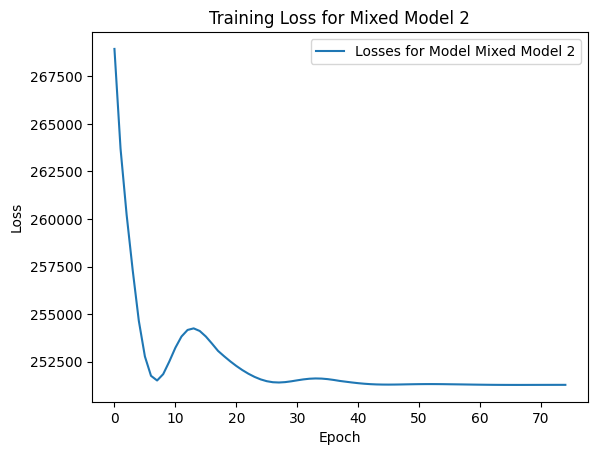

2025-06-26 18:32:59,979 - INFO - Initial Q (logit/softmax):
[[ 0.0329 -0.0118 -0.0294 -0.0071]
 [-0.0933  0.0369  0.048   0.0745]]

[[0.2593 0.248  0.2436 0.2491]
 [0.2235 0.2546 0.2575 0.2644]]
2025-06-26 18:32:59,980 - INFO - Initial m (logit/softmax):
[ 0.0376 -0.0031]

[0.5102 0.4898]
2025-06-26 18:32:59,981 - INFO - Trained Q (logit/softmax):
[[-0.0099  0.0048  0.004  -0.0182]
 [-0.6565  0.7115  0.7118 -0.6728]]

[[0.2487 0.2524 0.2522 0.2467]
 [0.1016 0.3991 0.3993 0.1   ]]
2025-06-26 18:32:59,983 - INFO - Trained m (logit/softmax):
[-0.4115  0.446 ]

[0.2979 0.7021]
2025-06-26 18:32:59,984 - INFO - Relative frequencies of nucleotides in generated data:
[array([0.2473, 0.2507, 0.2528, 0.2492]), array([0.0991, 0.3999, 0.4014, 0.0996])]

with weights:
[0.3, 0.7]


In [21]:
multi_model_test([ground_truth_1, ground_truth_3], [0.3, 0.7], "Mixed Model 2", 
                 lr=0.1, epochs=75, N=1000, seqlen=100, batch_size=1)

2025-06-26 18:33:00,007 - INFO - Testing model Mixed Model 1 perfect init with parameters: [array([0.25, 0.25, 0.25, 0.25]), array([0.1, 0.2, 0.3, 0.4]), array([0.1, 0.4, 0.4, 0.1])] and hyperparameters lr=0.01, epochs=75, N=1000, seqlen=100, tile_size=100, batch_size=1, K=3


2025-06-26 18:33:00,660 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-26 18:33:00,689 - INFO - [generate_data] Relative frequencies of nucleotides in generated data:
[array([0.2476, 0.2503, 0.2521, 0.2499]), array([0.1013, 0.2015, 0.2984, 0.3987]), array([0.1009, 0.3976, 0.4016, 0.0998])]
2025-06-26 18:33:00,696 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-26 18:33:00,710 - DEBUG - [background_model.__init__] >>> Q_logit shape: (3, 4), m_logit shape: (3,)
2025-06-26 18:33:00,723 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.01
2025-06-26 18:33:01.481024: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-26 18:33:01,486 - INFO - [background_model.train] >>> epoch     0 mean loss = 257755.9844, time: 0.76s
2025-06-26 18:33:01,487 - DEBUG - [background_model.train] >>> batch shape: (1, 1, 1000, 2, 100, 4)
2025-06-26 18:33:01.942710: W tensorflow/core/framework/l

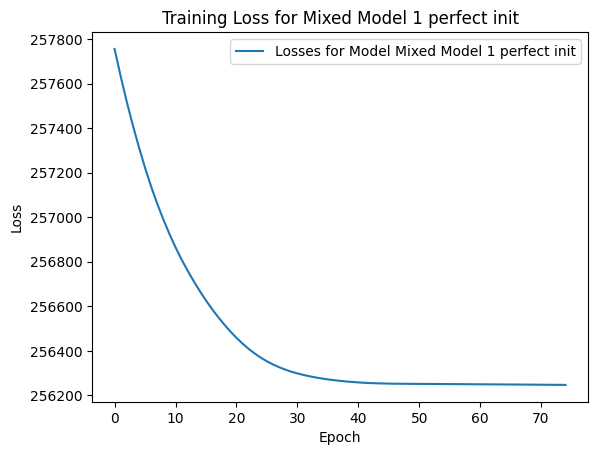

2025-06-26 18:33:34,014 - INFO - Initial Q (logit/softmax):
[[-1.3958 -1.3849 -1.3779 -1.3867]
 [-2.2893 -1.602  -1.2092 -0.9195]
 [-2.2932 -0.9223 -0.9122 -2.3043]]

[[0.2476 0.2503 0.2521 0.2499]
 [0.1013 0.2015 0.2984 0.3987]
 [0.1009 0.3976 0.4016 0.0998]]
2025-06-26 18:33:34,015 - INFO - Initial m (logit/softmax):
[-1.6094 -1.204  -0.6931]

[0.2 0.3 0.5]
2025-06-26 18:33:34,016 - INFO - Trained Q (logit/softmax):
[[-1.0897 -1.26   -1.4473 -1.7069]
 [-2.1608 -1.5738 -1.2274 -0.9619]
 [-2.2989 -0.9174 -0.9172 -2.2984]]

[[0.3244 0.2736 0.2269 0.175 ]
 [0.1155 0.2077 0.2937 0.3831]
 [0.1004 0.3996 0.3996 0.1004]]
2025-06-26 18:33:34,017 - INFO - Trained m (logit/softmax):
[-1.1431 -1.6853 -0.7691]

[0.3295 0.1916 0.4789]
2025-06-26 18:33:34,018 - INFO - Relative frequencies of nucleotides in generated data:
[array([0.2476, 0.2503, 0.2521, 0.2499]), array([0.1013, 0.2015, 0.2984, 0.3987]), array([0.1009, 0.3976, 0.4016, 0.0998])]

with weights:
[0.2, 0.3, 0.5]


In [22]:
multi_model_test([ground_truth_1, ground_truth_2, ground_truth_3], [0.2, 0.3, 0.5], "Mixed Model 1 perfect init", 
                 lr=0.01, epochs=75, N=1000, seqlen=100, batch_size=1, perfect_initialization=True)

2025-06-26 18:33:34,035 - INFO - Testing model Mixed Model 1, higher K with parameters: [array([0.25, 0.25, 0.25, 0.25]), array([0.1, 0.2, 0.3, 0.4]), array([0.1, 0.4, 0.4, 0.1])] and hyperparameters lr=0.01, epochs=75, N=1000, seqlen=100, tile_size=100, batch_size=1, K=4
2025-06-26 18:33:34,447 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-26 18:33:34,474 - INFO - [generate_data] Relative frequencies of nucleotides in generated data:
[array([0.2504, 0.2506, 0.2531, 0.2459]), array([0.1017, 0.1993, 0.2946, 0.4045]), array([0.0994, 0.3982, 0.4021, 0.1003])]
2025-06-26 18:33:34,481 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-26 18:33:34,492 - DEBUG - [background_model.__init__] >>> Q_logit shape: (4, 4), m_logit shape: (4,)
2025-06-26 18:33:34,502 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.01
2025-06-26 18:33:35.185607: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequ

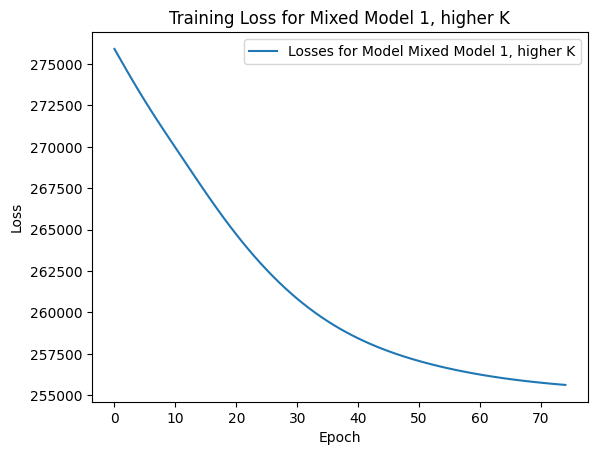

2025-06-26 18:34:07,792 - INFO - Initial Q (logit/softmax):
[[ 0.0329 -0.0118 -0.0294 -0.0071]
 [-0.0933  0.0369  0.048   0.0745]
 [-0.0547 -0.0554 -0.0379  0.0445]
 [-0.0734  0.0096  0.0149  0.0799]]

[[0.2593 0.248  0.2436 0.2491]
 [0.2235 0.2546 0.2575 0.2644]
 [0.2427 0.2425 0.2468 0.268 ]
 [0.2302 0.2501 0.2514 0.2683]]
2025-06-26 18:34:07,792 - INFO - Initial m (logit/softmax):
[ 0.0376 -0.0031  0.0862 -0.0496]

[0.2547 0.2445 0.2674 0.2334]
2025-06-26 18:34:07,793 - INFO - Trained Q (logit/softmax):
[[ 0.4324  0.2089 -0.0393 -0.4245]
 [-0.6202  0.6061  0.6085 -0.52  ]
 [-0.5806 -0.168   0.1091  0.3534]
 [-0.5358  0.5735  0.5303 -0.5298]]

[[0.3511 0.2808 0.2191 0.149 ]
 [0.112  0.3817 0.3826 0.1238]
 [0.1419 0.2143 0.2828 0.361 ]
 [0.1259 0.3818 0.3656 0.1267]]
2025-06-26 18:34:07,794 - INFO - Trained m (logit/softmax):
[-0.0337  0.4261 -0.1707 -0.7907]

[0.2548 0.4035 0.2222 0.1195]
2025-06-26 18:34:07,795 - INFO - Relative frequencies of nucleotides in generated data:
[array([

In [23]:
multi_model_test([ground_truth_1, ground_truth_2, ground_truth_3], [0.2, 0.3, 0.5], "Mixed Model 1, higher K", 
                 lr=0.01, epochs=75, N=1000, seqlen=100, batch_size=1, K=4)

---

In [90]:
import importlib
importlib.reload(background_model)

<module 'modules.background_model' from '/home/matthis/PhD/genomegraph/learn_specific_profiles/modules/background_model.py'>

In [4]:
def generate_higher_order_data(model: np.ndarray, weights: list[float], N: int, seqlen: int, 
                               tile_size: int, batch_size: int, alphabet: str = "ACGT") -> ModelDataSet.ModelDataSet:
    assert len(model.shape) >= 2, \
        "Model must be a >=2D array for multiple higher order Markov models. First dimension is K (number of models), "\
        + f"the remaining `order+1` dimensions are 4. Got shape: {model.shape}."
    num_models = model.shape[0]  # number of models
    size = len(alphabet)
    assert model.shape[1:] == (size,)*(len(model.shape)-1), \
        f"Model must be a higher order Markov model with ({size})^k rows for some int k, but got shape {model.shape}."
    assert len(weights) == num_models, \
        f"Number of weights must match number of models in the higher order Markov model, which is {num_models}. " \
            + f"Got {len(weights)}."
    assert np.isclose(np.sum(weights), 1.0), "Weights must sum to 1."
    
    k = len(model.shape) - 1  
    j = k - 1 # order of the Markov model
    assert k >= 1, "Model must be a zero or higher order Markov model with k >= 1."
    assert seqlen >= k, f"Sequence length must be at least k={k} for higher order Markov models. Got {seqlen}."
    
    # # reshape the model to a (4^(j), 4, K) array -> j-mers, ACGT, models
    # dense_model = model.reshape((4**(j), 4, num_models))
    # # check that the model is normalized
    # for mi in range(2):
    #     assert np.allclose(np.sum(dense_model[:,:,mi], axis=1), 1.0), \
    #         f"Model {mi} is not normalized. Sum of probabilities: {np.sum(dense_model[:,:,mi], axis=1)}"
    
    mod_sums = np.expand_dims( np.sum(model, axis=tuple(list(range(1,k+1)))), -1 )
    freqs = model.reshape((num_models, size**k)) / mod_sums # normalized, sum to 1
    assert np.allclose(np.sum(freqs, axis=1), 1.0), \
        f"Model frequencies are not normalized. Sum of probabilities: {np.sum(freqs, axis=1)}" # should not happen
    
    # start data generation
    raw_data = []
    chosen_models = []
    kmer_freqs = [{kmer: 0 for kmer in [''.join(p) for p in itertools.product([c for c in alphabet], repeat=k)]} \
                  for _ in range(num_models)]  # to store k-mer frequencies for each model
    for _ in range(N):
        # Choose a model based on the weights
        mi = random.choices(range(num_models), weights=weights, k=1)[0]
        chosen_models.append(mi)
        start_kmer_idx = random.choices(range(4**k), weights=freqs[mi, :], k=1)[0]
        idx_seq = list(np.unravel_index(start_kmer_idx, (size,)*k))  # Start with a random k-mer
        for i in range(k, seqlen): # Generate the rest of the sequence
            # Get the last j characters to determine the next character
            jmer_idcs = idx_seq[i-j:i]  # last j characters
            next_idx = random.choices(range(size), weights=model[(mi,)+tuple(jmer_idcs)], k=1)[0]
            idx_seq.append(next_idx)  # Append the next character index

        assert len(idx_seq) == seqlen, \
            f"Generated sequence length {len(idx_seq)} does not match expected length {seqlen}."
            
        # Convert the index sequence to a string
        seq = ''.join([alphabet[i] for i in idx_seq])

        # Update k-mer frequencies for the chosen model
        for i in range(seqlen - k + 1):
            kmer = seq[i:i+k]
            assert kmer in kmer_freqs[mi], \
                f"Generated k-mer {kmer} not in model alphabet {alphabet}." # should not happen
            kmer_freqs[mi][kmer] += 1

        # Append the sequence to the data list
        raw_data.append(seq)

    # Normalize k-mer frequencies
    for mi in range(num_models):
        total_count = sum(kmer_freqs[mi].values())
        if total_count > 0:
            for kmer in kmer_freqs[mi]:
                kmer_freqs[mi][kmer] /= total_count
        else:
            logging.warning(f"Model {mi} has no k-mers generated. Frequencies will be zero.")

    # Create a ModelDataSet object with the generated sequences
    genomes = [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=seq,
                                                                              source=f"model {chosen_models[i]}")]) \
                for i, seq in enumerate(raw_data)]
    data = ModelDataSet.ModelDataSet(genomes, ModelDataSet.DataMode.DNA,
                                     tile_size=tile_size, tiles_per_X=1, batch_size=batch_size, prefetch=1)
    assert ''.join(data.alphabet) == "ACGT", \
        f"[generate_data] Alphabet must be ACGT for this model, not {data.alphabet}."
    logging.debug(f"[generate_data] Steps per epoch: {data.getStepsPerEpoch()}.")

    return data, kmer_freqs

In [3]:
import importlib
importlib.reload(background_model)

<module 'modules.background_model' from '/home/matthis/PhD/genomegraph/learn_specific_profiles/modules/background_model.py'>

In [74]:
for order in [0, 1, 2]:
    model0, freqs0, alphabet = background_model.get_background_model(order=order, model_type="uniform")
    model1, freqs1, alphabet = background_model.get_background_model(order=order, model_type="random", seed=SEED)
    # model = np.zeros(model0.shape+(2,))
    # model[:, :, :, 0] = model0
    # model[:, :, :, 1] = model1
    k = len(model0.shape)
    model = np.array([model0, model1])#.transpose(tuple(range(1,k+1))+(0,))
    freqs = [freqs0, freqs1]
    weights = [0.5, 0.5]
    print(model.shape)

    data, data_kmer_freqs = generate_higher_order_data(model, weights, N, seqlen=1000, 
                                                       tile_size=tile_size, batch_size=batch_size, alphabet=alphabet)

    print(f"=== Order {order} ===")
    print("Comparing generated k-mer frequencies with expected model frequencies:")
    print()
    print("K-mer || gen. m0 | exp. m0 |   diff || gen. m1 | exp. m1 |   diff")
    print("------++---------+---------+--------++---------+---------+-------")
    for kmer in data_kmer_freqs[0]:
        print(f" {' '*(4-k)}{kmer} ||  {data_kmer_freqs[0][kmer]:.4f} |  {freqs[0][kmer]:.4f} | {abs(data_kmer_freqs[0][kmer]-freqs[0][kmer]):.4f} ||  {data_kmer_freqs[1][kmer]:.4f} |  {freqs[1][kmer]:.4f} | {abs(data_kmer_freqs[1][kmer]-freqs[1][kmer]):.4f}")

    print()


(2, 4)


2025-06-27 16:05:08,636 - DEBUG - [generate_data] Steps per epoch: 10.


=== Order 0 ===
Comparing generated k-mer frequencies with expected model frequencies:

K-mer || gen. m0 | exp. m0 |   diff || gen. m1 | exp. m1 |   diff
------++---------+---------+--------++---------+---------+-------
    A ||  0.2496 |  0.2500 | 0.0004 ||  0.1404 |  0.1410 | 0.0006
    C ||  0.2498 |  0.2500 | 0.0002 ||  0.3593 |  0.3580 | 0.0014
    G ||  0.2502 |  0.2500 | 0.0002 ||  0.2747 |  0.2756 | 0.0009
    T ||  0.2504 |  0.2500 | 0.0004 ||  0.2255 |  0.2254 | 0.0001

(2, 4, 4)


2025-06-27 16:05:15,218 - DEBUG - [generate_data] Steps per epoch: 10.


=== Order 1 ===
Comparing generated k-mer frequencies with expected model frequencies:

K-mer || gen. m0 | exp. m0 |   diff || gen. m1 | exp. m1 |   diff
------++---------+---------+--------++---------+---------+-------
   AA ||  0.0627 |  0.0625 | 0.0002 ||  0.0427 |  0.0386 | 0.0041
   AC ||  0.0622 |  0.0625 | 0.0003 ||  0.1081 |  0.0742 | 0.0338
   AG ||  0.0624 |  0.0625 | 0.0001 ||  0.0836 |  0.0344 | 0.0493
   AT ||  0.0627 |  0.0625 | 0.0002 ||  0.0686 |  0.0673 | 0.0014
   CA ||  0.0621 |  0.0625 | 0.0004 ||  0.0285 |  0.0345 | 0.0060
   CC ||  0.0623 |  0.0625 | 0.0002 ||  0.0288 |  0.0262 | 0.0026
   CG ||  0.0624 |  0.0625 | 0.0001 ||  0.0109 |  0.0059 | 0.0051
   CT ||  0.0629 |  0.0625 | 0.0004 ||  0.1607 |  0.2091 | 0.0484
   GA ||  0.0626 |  0.0625 | 0.0001 ||  0.0365 |  0.0715 | 0.0350
   GC ||  0.0625 |  0.0625 | 0.0000 ||  0.0423 |  0.0639 | 0.0216
   GG ||  0.0624 |  0.0625 | 0.0001 ||  0.0011 |  0.0011 | 0.0000
   GT ||  0.0625 |  0.0625 | 0.0000 ||  0.0584 |  0.12

2025-06-27 16:05:21,737 - DEBUG - [generate_data] Steps per epoch: 10.


=== Order 2 ===
Comparing generated k-mer frequencies with expected model frequencies:

K-mer || gen. m0 | exp. m0 |   diff || gen. m1 | exp. m1 |   diff
------++---------+---------+--------++---------+---------+-------
  AAA ||  0.0153 |  0.0156 | 0.0004 ||  0.0053 |  0.0099 | 0.0047
  AAC ||  0.0158 |  0.0156 | 0.0001 ||  0.0137 |  0.0191 | 0.0054
  AAG ||  0.0155 |  0.0156 | 0.0001 ||  0.0107 |  0.0089 | 0.0018
  AAT ||  0.0154 |  0.0156 | 0.0002 ||  0.0089 |  0.0173 | 0.0084
  ACA ||  0.0159 |  0.0156 | 0.0003 ||  0.0069 |  0.0089 | 0.0020
  ACC ||  0.0158 |  0.0156 | 0.0002 ||  0.0070 |  0.0067 | 0.0002
  ACG ||  0.0157 |  0.0156 | 0.0001 ||  0.0026 |  0.0015 | 0.0011
  ACT ||  0.0158 |  0.0156 | 0.0002 ||  0.0382 |  0.0539 | 0.0157
  AGA ||  0.0158 |  0.0156 | 0.0001 ||  0.0211 |  0.0184 | 0.0026
  AGC ||  0.0157 |  0.0156 | 0.0001 ||  0.0245 |  0.0165 | 0.0081
  AGG ||  0.0156 |  0.0156 | 0.0000 ||  0.0006 |  0.0003 | 0.0004
  AGT ||  0.0159 |  0.0156 | 0.0002 ||  0.0341 |  0.03

In [72]:
for order in [0, 1, 2]:
    model0, freqs0, alphabet = background_model.get_background_model(order=order, model_type="uniform")
    model1, freqs1, alphabet = background_model.get_background_model(order=order, model_type="random", seed=SEED)
    # model = np.zeros(model0.shape+(2,))
    # model[:, :, :, 0] = model0
    # model[:, :, :, 1] = model1
    k = len(model0.shape)
    model = np.array([model0, model1])#.transpose(tuple(range(1,k+1))+(0,))
    freqs = [freqs0, freqs1]
    weights = [0.5, 0.5]
    print(model.shape)

    data, data_kmer_freqs = generate_higher_order_data(model, weights, N, seqlen=1000, 
                                                       tile_size=tile_size, batch_size=batch_size, alphabet=alphabet)

    # reconstruct the model from the data
    model_reconstructed = np.zeros(model.shape)
    for mi in range(model.shape[0]):
        for i, (kmer, freq) in enumerate(data_kmer_freqs[mi].items()):
            kmer_idx = np.unravel_index(i, (len(alphabet),)*k)
            # print(f"[DEBUG] Reconstructing k-mer {kmer} with frequency {freq} for model {mi} | model shape {model_reconstructed.shape} | kmer index in model {kmer_idx}")
            model_reconstructed[(mi,)+kmer_idx] = freq

    # normalize the models
    model_reconstructed /= np.sum(model_reconstructed, axis=-1, keepdims=True)

    print(f"=== Order {order} Reconstructed ===")
    print(f"Ground Truth Model:\n{model[0]}\n")
    print(f"Reconstructed Model:\n{model_reconstructed[0]}\n")
    print(f"Difference:\n{np.abs(model[0] - model_reconstructed[0])}\n")
    print(f"Ground Truth Model:\n{model[1]}\n")
    print(f"Reconstructed Model:\n{model_reconstructed[1]}\n")
    print(f"Difference:\n{np.abs(model[1] - model_reconstructed[1])}\n")
    print()


(2, 4)


2025-06-27 16:02:50,824 - DEBUG - [generate_data] Steps per epoch: 10.


=== Order 0 Reconstructed ===
Ground Truth Model:
[0.25 0.25 0.25 0.25]

Reconstructed Model:
[0.2502 0.2502 0.2498 0.2498]

Difference:
[0.0002 0.0002 0.0002 0.0002]

Ground Truth Model:
[0.141  0.358  0.2756 0.2254]

Reconstructed Model:
[0.1411 0.3575 0.2759 0.2255]

Difference:
[0.0001 0.0005 0.0002 0.0001]


(2, 4, 4)


2025-06-27 16:02:57,019 - DEBUG - [generate_data] Steps per epoch: 10.


=== Order 1 Reconstructed ===
Ground Truth Model:
[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]

Reconstructed Model:
[[0.2505 0.2498 0.2497 0.25  ]
 [0.2493 0.2505 0.2509 0.2494]
 [0.2496 0.2523 0.2491 0.249 ]
 [0.2484 0.2497 0.2513 0.2505]]

Difference:
[[0.0005 0.0002 0.0003 0.    ]
 [0.0007 0.0005 0.0009 0.0006]
 [0.0004 0.0023 0.0009 0.001 ]
 [0.0016 0.0003 0.0013 0.0005]]

Ground Truth Model:
[[0.141  0.358  0.2756 0.2254]
 [0.1262 0.1262 0.047  0.7006]
 [0.2614 0.3079 0.009  0.4218]
 [0.5904 0.1506 0.129  0.1301]]

Reconstructed Model:
[[0.1401 0.3576 0.277  0.2254]
 [0.1271 0.1253 0.0458 0.7018]
 [0.2618 0.3076 0.009  0.4216]
 [0.5903 0.1507 0.1288 0.1302]]

Difference:
[[0.001  0.0004 0.0013 0.    ]
 [0.0009 0.0009 0.0012 0.0012]
 [0.0004 0.0003 0.     0.0001]
 [0.0001 0.0001 0.0002 0.0001]]


(2, 4, 4, 4)


2025-06-27 16:03:03,424 - DEBUG - [generate_data] Steps per epoch: 10.


=== Order 2 Reconstructed ===
Ground Truth Model:
[[[0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]]

 [[0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]]

 [[0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]]

 [[0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]]]

Reconstructed Model:
[[[0.2544 0.2483 0.25   0.2473]
  [0.2521 0.2525 0.2454 0.25  ]
  [0.2449 0.2532 0.2516 0.2503]
  [0.2523 0.2495 0.249  0.2493]]

 [[0.2533 0.2464 0.2477 0.2526]
  [0.2533 0.249  0.2494 0.2484]
  [0.2533 0.248  0.2498 0.2489]
  [0.251  0.2526 0.243  0.2534]]

 [[0.249  0.2489 0.2511 0.2509]
  [0.2542 0.2507 0.2465 0.2486]
  [0.251  0.2517 0.25   0.2473]
  [0.2488 0.2509 0.2514 0.2489]]

 [[0.2495 0.2514 0.2472 0.2518]
  [0.2485 0.2501 0.2494 0.2521]
  [0.2474 0.254  0.2517 0.2468]
  [0.2525 0.2488 0.2452 0.2535]]]

Difference:
[[[

In [7]:
def higher_order_model_test(ground_truths: np.ndarray, weights: list[float], name: str, K: int = None,
                            lr: float = 0.1, epochs: int = 50, N: int = N, seqlen: int = seqlen, tile_size: int = tile_size, 
                            batch_size: int = batch_size):
    """ K: manually set the number of learned models, otherwise defaults to the number of ground_truths models """
    assert len(ground_truths.shape) >= 2, \
        f"ground_truths must be of shape (K,)+(4)*k for some k>0. Got {ground_truths.shape}"
    assert ground_truths.shape[0] == len(weights), "Number of ground truth models must match number of weights."
    if K is None:
        K = ground_truths.shape[0]
    else:
        assert K >= 1, f"Need to train at least one model, got {K=}"
    logging.info(f"Testing model {name} with parameters: {ground_truths} " \
                 + f"and hyperparameters {lr=}, {epochs=}, {N=}, {seqlen=}, {tile_size=}, {batch_size=}, {K=}")
    
    data, relative_frequencies = generate_higher_order_data(ground_truths, weights, N, seqlen, tile_size, batch_size)
    k_dims = len(ground_truths.shape) - 1
    order = k_dims - 1
    model = background_model.TrainedQ(data, num_models=K, order=order, rand_seed=SEED)

    # not implemented yet
    # if perfect_initialization:
    #     # Initialize the model with the relative frequencies of the nucleotides in the generated data
    #     model.Q_logit.assign(np.log(np.array(relative_frequencies).transpose()))
    #     model.m_logit.assign(np.log(weights))  # Initialize m to 1.0 for simplicity

    # get initial model parameters
    Q_init_raw = model.Q_logit.numpy()
    Q_init = model.getQ().numpy()
    m_init_raw = model.m_logit.numpy()
    m_init = model.getM().numpy()
    
    # Fit the background model
    losses = model.train(lr, epochs)

    # plot losses
    plt.plot(losses, label=f'Losses for Model {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training Loss for {name}')
    plt.legend()
    plt.show()

    # Get the trained model parameters
    Q_trained_raw = model.Q_logit.numpy()
    Q_trained = model.getQ().numpy()
    m_trained_raw = model.m_logit.numpy()
    m_trained = model.getM().numpy()

    logging.info(f"Initial Q (logit/softmax):\n{Q_init_raw}\n\n{Q_init}")
    logging.info(f"Initial m (logit/softmax):\n{m_init_raw}\n\n{m_init}")
    logging.info(f"Trained Q (logit/softmax):\n{Q_trained_raw}\n\n{Q_trained}")
    logging.info(f"Trained m (logit/softmax):\n{m_trained_raw}\n\n{m_trained}")
    logging.info(f"Ground truth of generated data:\n{ground_truths}\n\nwith weights:\n{weights}")

    return model, losses, data, relative_frequencies

2025-06-26 19:08:07,898 - INFO - Testing model First order, 1 model, uniform with parameters: [[[0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]]] and hyperparameters lr=0.1, epochs=50, N=1000, seqlen=500, tile_size=500, batch_size=1, K=1
2025-06-26 19:08:11,167 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-26 19:08:11,173 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-26 19:08:11,188 - DEBUG - [background_model.__init__] >>> Q_logit shape: (1, 4, 4), m_logit shape: (1,)
2025-06-26 19:08:11,199 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.1
2025-06-26 19:08:22.740518: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-26 19:08:22,744 - INFO - [background_model.train] >>> epoch     0 mean loss = 1385017.7500, time: 11.54s
2025-06-26 19:08:22,744 - DEBUG - [background_model.train] >>> batch shape: (1, 1, 1000, 2, 499, 

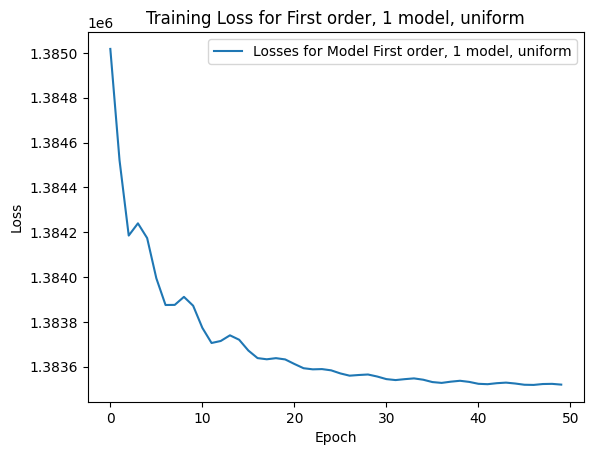

2025-06-26 19:17:17,507 - INFO - Initial Q (logit/softmax):
[[[ 0.0329 -0.0118 -0.0294 -0.0071]
  [-0.0933  0.0369  0.048   0.0745]
  [-0.0547 -0.0554 -0.0379  0.0445]
  [-0.0734  0.0096  0.0149  0.0799]]]

[[[0.2593 0.248  0.2436 0.2491]
  [0.2235 0.2546 0.2575 0.2644]
  [0.2427 0.2425 0.2468 0.268 ]
  [0.2302 0.2501 0.2514 0.2683]]]
2025-06-26 19:17:17,508 - INFO - Initial m (logit/softmax):
[0.0376]

[1.]
2025-06-26 19:17:17,509 - INFO - Trained Q (logit/softmax):
[[[ 0.006   0.0164  0.0129  0.0162]
  [-0.0253 -0.027  -0.0223 -0.0163]
  [ 0.0113 -0.0041  0.0001  0.0053]
  [ 0.0181  0.0084  0.012   0.0109]]]

[[[0.2483 0.2509 0.25   0.2508]
  [0.2494 0.2489 0.2501 0.2516]
  [0.252  0.2482 0.2492 0.2505]
  [0.2514 0.249  0.2499 0.2496]]]
2025-06-26 19:17:17,509 - INFO - Trained m (logit/softmax):
[0.0376]

[1.]
2025-06-26 19:17:17,510 - INFO - Ground truth of generated data:
[[[0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]]]

with weights

In [ ]:
model0, freqs0, alphabet = background_model.get_background_model(order=1, model_type="uniform")
ground_truth_higher_order = np.array([model0])
weights = [1]
_, _, _, _ = higher_order_model_test(ground_truth_higher_order, weights, "First order, 1 model, uniform",
                        lr=0.1, epochs=50, N=1000, seqlen=500, tile_size=500, batch_size=1)

2025-06-26 19:17:17,526 - INFO - Testing model First order, 1 model, random with parameters: [[[0.141  0.358  0.2756 0.2254]
  [0.1262 0.1262 0.047  0.7006]
  [0.2614 0.3079 0.009  0.4218]
  [0.5904 0.1506 0.129  0.1301]]] and hyperparameters lr=0.1, epochs=50, N=1000, seqlen=500, tile_size=500, batch_size=1, K=2
2025-06-26 19:17:20,790 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-26 19:17:20,795 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-26 19:17:20,807 - DEBUG - [background_model.__init__] >>> Q_logit shape: (2, 4, 4), m_logit shape: (2,)
2025-06-26 19:17:20,820 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.1
2025-06-26 19:17:33.428827: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-26 19:17:33,432 - INFO - [background_model.train] >>> epoch     0 mean loss = 1323361.7500, time: 12.61s
2025-06-26 19:17:33,433 - DEBUG - [background_model.train] >>> bat

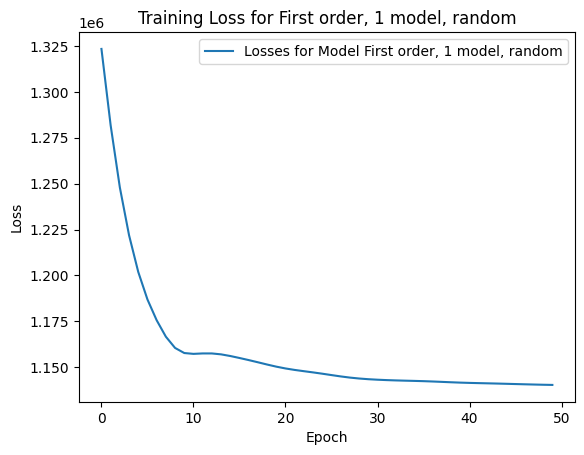

2025-06-26 19:26:37,642 - INFO - Initial Q (logit/softmax):
[[[ 0.0329 -0.0118 -0.0294 -0.0071]
  [-0.0933  0.0369  0.048   0.0745]
  [-0.0547 -0.0554 -0.0379  0.0445]
  [-0.0734  0.0096  0.0149  0.0799]]

 [[-0.0981  0.0042  0.0269 -0.0601]
  [ 0.0459  0.0092 -0.0785  0.0353]
  [ 0.0321 -0.0326  0.0203 -0.0579]
  [ 0.0705 -0.0119  0.0897 -0.0525]]]

[[[0.2593 0.248  0.2436 0.2491]
  [0.2235 0.2546 0.2575 0.2644]
  [0.2427 0.2425 0.2468 0.268 ]
  [0.2302 0.2501 0.2514 0.2683]]

 [[0.2337 0.2588 0.2648 0.2427]
  [0.2607 0.2513 0.2302 0.2579]
  [0.2604 0.2441 0.2574 0.238 ]
  [0.2615 0.2408 0.2665 0.2312]]]
2025-06-26 19:26:37,642 - INFO - Initial m (logit/softmax):
[ 0.0376 -0.0031]

[0.5102 0.4898]
2025-06-26 19:26:37,643 - INFO - Trained Q (logit/softmax):
[[[-0.5286  0.3799  0.1504 -0.0655]
  [-0.5447 -0.4813 -1.3768  1.2085]
  [ 1.56    1.7361 -2.2489  2.0506]
  [ 0.7403 -0.6556 -0.8128 -0.7727]]

 [[-0.7245 -0.359   0.6615 -0.2055]
  [ 0.5307 -2.2304 -1.0583  1.3205]
  [-0.1962 -0.

In [ ]:
model1, freqs1, alphabet = background_model.get_background_model(order=1, model_type="random", seed=SEED)
ground_truth_higher_order = np.array([model1])
weights = [1]
_, _, _, _ = higher_order_model_test(ground_truth_higher_order, weights, "First order, 1 model, random", K=2,
                        lr=0.1, epochs=50, N=1000, seqlen=500, tile_size=500, batch_size=1)

2025-06-26 18:58:23,761 - INFO - Testing model First order, 2 models with parameters: [[[0.25   0.25   0.25   0.25  ]
  [0.25   0.25   0.25   0.25  ]
  [0.25   0.25   0.25   0.25  ]
  [0.25   0.25   0.25   0.25  ]]

 [[0.141  0.358  0.2756 0.2254]
  [0.1262 0.1262 0.047  0.7006]
  [0.2614 0.3079 0.009  0.4218]
  [0.5904 0.1506 0.129  0.1301]]] and hyperparameters lr=0.1, epochs=50, N=1000, seqlen=500, tile_size=500, batch_size=1, K=3
2025-06-26 18:58:27,115 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-26 18:58:27,121 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-26 18:58:27,135 - DEBUG - [background_model.__init__] >>> Q_logit shape: (3, 4, 4), m_logit shape: (3,)
2025-06-26 18:58:27,150 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.1
2025-06-26 18:58:40.710277: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-26 18:58:40,713 - INFO - [background_model.train

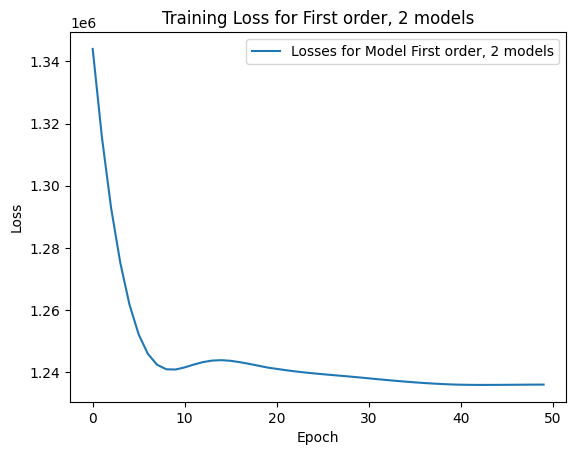

2025-06-26 19:08:07,875 - INFO - Initial Q (logit/softmax):
[[[ 0.0329 -0.0118 -0.0294 -0.0071]
  [-0.0933  0.0369  0.048   0.0745]
  [-0.0547 -0.0554 -0.0379  0.0445]
  [-0.0734  0.0096  0.0149  0.0799]]

 [[-0.0981  0.0042  0.0269 -0.0601]
  [ 0.0459  0.0092 -0.0785  0.0353]
  [ 0.0321 -0.0326  0.0203 -0.0579]
  [ 0.0705 -0.0119  0.0897 -0.0525]]

 [[ 0.0624  0.0053 -0.0011 -0.0568]
  [ 0.0691  0.0744 -0.0383  0.0374]
  [-0.0525  0.0563  0.0934 -0.0863]
  [ 0.0597  0.0321  0.0174 -0.0671]]]

[[[0.2593 0.248  0.2436 0.2491]
  [0.2235 0.2546 0.2575 0.2644]
  [0.2427 0.2425 0.2468 0.268 ]
  [0.2302 0.2501 0.2514 0.2683]]

 [[0.2337 0.2588 0.2648 0.2427]
  [0.2607 0.2513 0.2302 0.2579]
  [0.2604 0.2441 0.2574 0.238 ]
  [0.2615 0.2408 0.2665 0.2312]]

 [[0.2652 0.2505 0.2489 0.2354]
  [0.2583 0.2596 0.2319 0.2502]
  [0.2359 0.263  0.273  0.2281]
  [0.2623 0.2552 0.2515 0.2311]]]
2025-06-26 19:08:07,877 - INFO - Initial m (logit/softmax):
[ 0.0376 -0.0031  0.0862]

[0.3322 0.319  0.3488]
2

In [ ]:
model0, freqs0, alphabet = background_model.get_background_model(order=1, model_type="uniform")
model1, freqs1, alphabet = background_model.get_background_model(order=1, model_type="random", seed=SEED)
ground_truth_higher_order = np.array([model0, model1])
weights = [0.3, 0.7]
_, _, _, _ = higher_order_model_test(ground_truth_higher_order, weights, "First order, 2 models", K=3,
                        lr=0.1, epochs=50, N=1000, seqlen=500, tile_size=500, batch_size=1)

2025-06-27 18:08:10,577 - INFO - Testing model Second order, 1 model, random with parameters: [[[[0.141  0.358  0.2756 0.2254]
   [0.1262 0.1262 0.047  0.7006]
   [0.2614 0.3079 0.009  0.4218]
   [0.5904 0.1506 0.129  0.1301]]

  [[0.196  0.3381 0.2783 0.1876]
   [0.434  0.0989 0.2072 0.2599]
   [0.2333 0.4016 0.1021 0.263 ]
   [0.4181 0.0328 0.4288 0.1203]]

  [[0.0233 0.3404 0.3464 0.29  ]
   [0.1995 0.064  0.4482 0.2883]
   [0.0782 0.3172 0.022  0.5826]
   [0.1476 0.3779 0.1778 0.2967]]

  [[0.2208 0.0746 0.3915 0.313 ]
   [0.2801 0.2668 0.1783 0.2748]
   [0.1351 0.2992 0.069  0.4967]
   [0.2106 0.147  0.4491 0.1933]]]] and hyperparameters lr=0.1, epochs=50, N=1000, seqlen=500, tile_size=500, batch_size=1, K=2
2025-06-27 18:08:13,725 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-27 18:08:13,730 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-27 18:08:13.735241: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTER

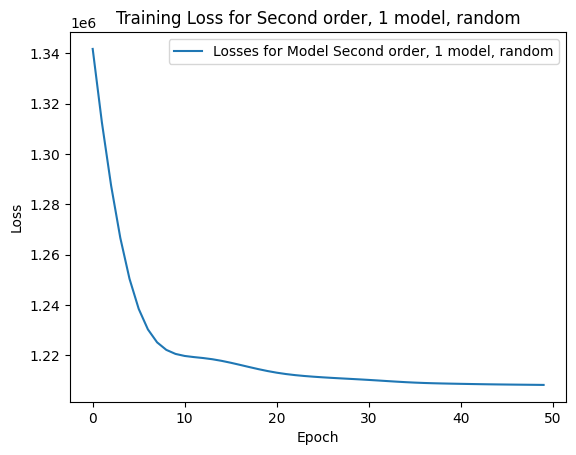

2025-06-27 18:22:03,551 - INFO - Initial Q (logit/softmax):
[[[[ 0.0329 -0.0118 -0.0294 -0.0071]
   [-0.0933  0.0369  0.048   0.0745]
   [-0.0547 -0.0554 -0.0379  0.0445]
   [-0.0734  0.0096  0.0149  0.0799]]

  [[-0.0981  0.0042  0.0269 -0.0601]
   [ 0.0459  0.0092 -0.0785  0.0353]
   [ 0.0321 -0.0326  0.0203 -0.0579]
   [ 0.0705 -0.0119  0.0897 -0.0525]]

  [[ 0.0624  0.0053 -0.0011 -0.0568]
   [ 0.0691  0.0744 -0.0383  0.0374]
   [-0.0525  0.0563  0.0934 -0.0863]
   [ 0.0597  0.0321  0.0174 -0.0671]]

  [[ 0.0476 -0.0359  0.0215 -0.007 ]
   [ 0.0956  0.0445 -0.0353  0.0652]
   [-0.0005 -0.061   0.0518 -0.0324]
   [-0.0437 -0.037   0.0213  0.05  ]]]


 [[[ 0.0003 -0.0634 -0.0736  0.0293]
   [ 0.0912  0.0334 -0.0385 -0.0262]
   [-0.0105 -0.0633  0.0058  0.0411]
   [ 0.0797 -0.0372  0.0247  0.0936]]

  [[-0.0776 -0.0408  0.0871 -0.0732]
   [-0.0361 -0.0475 -0.0937  0.0801]
   [ 0.0282  0.0164 -0.0582  0.0435]
   [-0.0273 -0.0907 -0.07    0.0687]]

  [[ 0.0871 -0.081  -0.0828  0.025 ]
 

In [8]:
model2, freqs2, alphabet = background_model.get_background_model(order=2, model_type="random", seed=SEED)
ground_truth_higher_order = np.array([model2])
weights = [1]
trained_model, trained_model_losses, training_data, training_data_freqs = higher_order_model_test(
    ground_truth_higher_order, weights, "Second order, 1 model, random", K=2,
    lr=0.1, epochs=50, N=1000, seqlen=500, tile_size=500, batch_size=1)

```
Ground truth of generated data:         Model 0                            Model 1
    [[[[0.141  0.358  0.2756 0.2254]    [[[0.1438 0.3566 0.2776 0.2221]    [[[0.203  0.4977 0.1695 0.1298]
       [0.1262 0.1262 0.047  0.7006]      [0.1166 0.116  0.0429 0.7246]      [0.4409 0.0779 0.1324 0.3487]
       [0.2614 0.3079 0.009  0.4218]      [0.26   0.3105 0.0062 0.4233]      [0.1885 0.2565 0.1034 0.4516]
       [0.5904 0.1506 0.129  0.1301]]     [0.5912 0.1584 0.1257 0.1247]]     [0.5045 0.2135 0.1448 0.1372]]

      [[0.196  0.3381 0.2783 0.1876]     [[0.1933 0.341  0.2802 0.1856]     [[0.3039 0.2027 0.4079 0.0855]
       [0.434  0.0989 0.2072 0.2599]      [0.4332 0.0942 0.2077 0.2649]      [0.4899 0.0201 0.4335 0.0565]
       [0.2333 0.4016 0.1021 0.263 ]      [0.2392 0.4019 0.0955 0.2634]      [0.2009 0.6322 0.1244 0.0424]
       [0.4181 0.0328 0.4288 0.1203]]     [0.4193 0.0308 0.4237 0.1262]]     [0.4905 0.2051 0.1703 0.134 ]]

      [[0.0233 0.3404 0.3464 0.29  ]     [[0.0174 0.3389 0.356  0.2877]     [[0.1573 0.6412 0.0439 0.1576]
       [0.1995 0.064  0.4482 0.2883]      [0.1946 0.0706 0.4492 0.2856]      [0.3423 0.0543 0.2795 0.3239]
       [0.0782 0.3172 0.022  0.5826]      [0.0984 0.32   0.0173 0.5643]      [0.4985 0.1611 0.1072 0.2332]
       [0.1476 0.3779 0.1778 0.2967]]     [0.1449 0.3758 0.1804 0.2989]]     [0.1319 0.2965 0.3175 0.2542]]

      [[0.2208 0.0746 0.3915 0.313 ]     [[0.2235 0.0697 0.396  0.3108]     [[0.1309 0.1471 0.3521 0.3699]
       [0.2801 0.2668 0.1783 0.2748]      [0.2825 0.2616 0.1808 0.2752]      [0.2547 0.0161 0.2737 0.4554]
       [0.1351 0.2992 0.069  0.4967]      [0.1371 0.299  0.0767 0.4872]      [0.3093 0.306  0.2427 0.142 ]
       [0.2106 0.147  0.4491 0.1933]]]]   [0.2039 0.1449 0.4571 0.1941]]]    [0.59   0.0231 0.2553 0.1316]]]
```

In [36]:
importlib.reload(background_model)

<module 'modules.background_model' from '/home/matthis/PhD/genomegraph/learn_specific_profiles/modules/background_model.py'>

2025-06-27 18:33:04,956 - INFO - Testing model Second order, 1 model, random with parameters: [[[[0.141  0.358  0.2756 0.2254]
   [0.1262 0.1262 0.047  0.7006]
   [0.2614 0.3079 0.009  0.4218]
   [0.5904 0.1506 0.129  0.1301]]

  [[0.196  0.3381 0.2783 0.1876]
   [0.434  0.0989 0.2072 0.2599]
   [0.2333 0.4016 0.1021 0.263 ]
   [0.4181 0.0328 0.4288 0.1203]]

  [[0.0233 0.3404 0.3464 0.29  ]
   [0.1995 0.064  0.4482 0.2883]
   [0.0782 0.3172 0.022  0.5826]
   [0.1476 0.3779 0.1778 0.2967]]

  [[0.2208 0.0746 0.3915 0.313 ]
   [0.2801 0.2668 0.1783 0.2748]
   [0.1351 0.2992 0.069  0.4967]
   [0.2106 0.147  0.4491 0.1933]]]] and hyperparameters lr=0.1, epochs=5, N=100, seqlen=100, tile_size=100, batch_size=1, K=2
2025-06-27 18:33:05,042 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-27 18:33:05,044 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-27 18:33:05,056 - DEBUG - [background_model.__init__] >>> Q_logit shape: (2, 4, 4, 4), m_logit shape: (2,)
2025-06-27

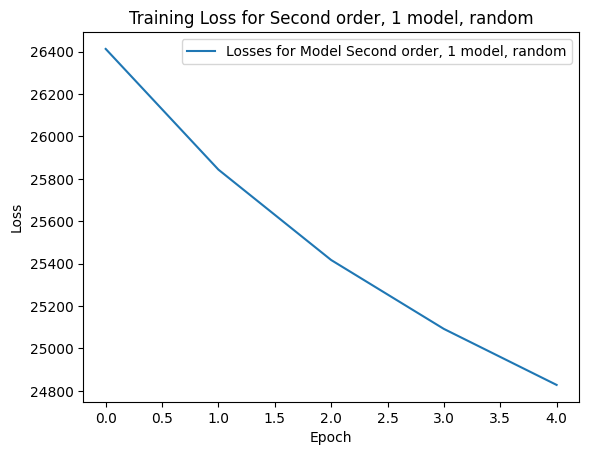

2025-06-27 18:33:07,439 - INFO - Initial Q (logit/softmax):
[[[[ 0.0329 -0.0118 -0.0294 -0.0071]
   [-0.0933  0.0369  0.048   0.0745]
   [-0.0547 -0.0554 -0.0379  0.0445]
   [-0.0734  0.0096  0.0149  0.0799]]

  [[-0.0981  0.0042  0.0269 -0.0601]
   [ 0.0459  0.0092 -0.0785  0.0353]
   [ 0.0321 -0.0326  0.0203 -0.0579]
   [ 0.0705 -0.0119  0.0897 -0.0525]]

  [[ 0.0624  0.0053 -0.0011 -0.0568]
   [ 0.0691  0.0744 -0.0383  0.0374]
   [-0.0525  0.0563  0.0934 -0.0863]
   [ 0.0597  0.0321  0.0174 -0.0671]]

  [[ 0.0476 -0.0359  0.0215 -0.007 ]
   [ 0.0956  0.0445 -0.0353  0.0652]
   [-0.0005 -0.061   0.0518 -0.0324]
   [-0.0437 -0.037   0.0213  0.05  ]]]


 [[[ 0.0003 -0.0634 -0.0736  0.0293]
   [ 0.0912  0.0334 -0.0385 -0.0262]
   [-0.0105 -0.0633  0.0058  0.0411]
   [ 0.0797 -0.0372  0.0247  0.0936]]

  [[-0.0776 -0.0408  0.0871 -0.0732]
   [-0.0361 -0.0475 -0.0937  0.0801]
   [ 0.0282  0.0164 -0.0582  0.0435]
   [-0.0273 -0.0907 -0.07    0.0687]]

  [[ 0.0871 -0.081  -0.0828  0.025 ]
 

In [39]:
model2, freqs2, alphabet = background_model.get_background_model(order=2, model_type="random", seed=SEED)
ground_truth_higher_order = np.array([model2])
weights = [1]
trained_model, trained_model_losses, training_data, training_data_freqs = higher_order_model_test(
    ground_truth_higher_order, weights, "Second order, 1 model, random", K=2,
    lr=0.1, epochs=5, N=100, seqlen=100, tile_size=100, batch_size=1)

scan = trained_model.scan_data(window_size=10)

In [40]:
scan.shape

(1, 1, 100, 2, 91, 2)

In [41]:
scan

array([[[[[[ -8.8623,  -9.2747],
           [-10.545 , -10.9315],
           [-11.3605, -11.6738],
           ...,
           [-11.3267, -11.5475],
           [-12.4745, -12.6942],
           [-12.0968, -12.7471]],

          [[-10.9846, -10.4961],
           [-12.0058, -11.4678],
           [-12.9894, -12.62  ],
           ...,
           [-13.016 , -12.5791],
           [-11.8343, -11.5667],
           [-11.9328, -11.5347]]],


         [[[ -9.1621,  -9.7953],
           [-10.3692, -10.9939],
           [-12.4429, -12.8115],
           ...,
           [-13.2526, -14.2866],
           [-13.1338, -14.1146],
           [-12.4042, -13.3434]],

          [[-11.2968, -10.5277],
           [-12.9702, -11.7561],
           [-14.8764, -13.6158],
           ...,
           [-13.1696, -12.1538],
           [-12.8196, -12.1827],
           [-12.3683, -12.2245]]],


         [[[ -9.9343,  -9.8768],
           [-10.9179, -11.0291],
           [-12.1991, -12.4869],
           ...,
           [-13.6

In [29]:
assert False, "Stop here"

AssertionError: Stop here

In [ ]:
# def higher_order_model_test(ground_truths: np.ndarray, weights: list[float], name: str, K: int = None,
#                             lr: float = 0.1, epochs: int = 50, N: int = N, seqlen: int = seqlen, tile_size: int = tile_size, 
#                             batch_size: int = batch_size, perfect_initialization: bool = False):
#     """ double_K: If True, learn twice as many models as in ground_truths, might help with asymmetric distributions
#         ~~perfect_initialization: If True, initializes the model with the relative nt frequencies of the data.~~ """
#     assert len(ground_truths.shape) == 2, f"ground_truths must be a matrix of (4^k, K). Got {ground_truths.shape}"
#     assert ground_truths.shape[1] == len(weights), "Number of ground truth models must match number of weights."
#     if K is None:
#         K = ground_truths.shape[1]
#     else:
#         assert K >= 1, f"Need to train at least one model, got {K=}"
#     logging.info(f"Testing model {name} with parameters: {ground_truths} " \
#                  + f"and hyperparameters {lr=}, {epochs=}, {N=}, {seqlen=}, {tile_size=}, {batch_size=}, {K=}")
    
#     data, relative_frequencies = generate_higher_order_data(ground_truths, weights, N, seqlen, tile_size, batch_size)
#     order = int(np.log2(ground_truths.shape[0]) / 2) - 1
#     model = background_model.TrainedQ(num_models=K, order=order, rand_seed=SEED)

#     # not implemented yet
#     # if perfect_initialization:
#     #     # Initialize the model with the relative frequencies of the nucleotides in the generated data
#     #     model.Q_logit.assign(np.log(np.array(relative_frequencies).transpose()))
#     #     model.m_logit.assign(np.log(weights))  # Initialize m to 1.0 for simplicity

#     # get initial model parameters
#     Q_init_raw = model.Q_logit.numpy()
#     Q_init = model.getQ().numpy()
#     m_init_raw = model.m_logit.numpy()
#     m_init = model.getM().numpy()
    
#     # Fit the background model
#     losses = model.train(data, lr, epochs)

#     # plot losses
#     plt.plot(losses, label=f'Losses for Model {name}')
#     plt.xlabel('Epoch')
#     plt.ylabel('Loss')
#     plt.title(f'Training Loss for {name}')
#     plt.legend()
#     plt.show()

#     # Get the trained model parameters
#     Q_trained_raw = model.Q_logit.numpy()
#     Q_trained = model.getQ().numpy()
#     m_trained_raw = model.m_logit.numpy()
#     m_trained = model.getM().numpy()

#     logging.info(f"Initial Q (logit/softmax):\n{Q_init_raw}\n\n{Q_init}")
#     logging.info(f"Initial m (logit/softmax):\n{m_init_raw}\n\n{m_init}")
#     logging.info(f"Trained Q (logit/softmax):\n{Q_trained_raw}\n\n{Q_trained}")
#     logging.info(f"Trained m (logit/softmax):\n{m_trained_raw}\n\n{m_trained}")
#     logging.info(f"Ground truth of generated data:\n{ground_truths}\n\nwith weights:\n{weights}")

In [ ]:
# import itertools

# def generate_higher_order_data(model: np.ndarray, weights: list[float], N: int, seqlen: int, 
#                                tile_size: int, batch_size: int, alphabet: str = "ACGT") -> ModelDataSet.ModelDataSet:
#     assert len(model.shape) == 2, \
#         "Model must be a 2D array for higher order Markov models. First dimension is 4^(order+1), " \
#             + f"second dimension is K (number of models). Got shape: {model.shape}."
#     num_models = model.shape[1]
#     assert len(weights) == num_models, \
#         f"Number of weights must match number of models in the higher order Markov model, which is {num_models}. " \
#             + f"Got {len(weights)}."
#     assert np.isclose(np.sum(weights), 1.0), "Weights must sum to 1."
    
#     # model.shape[0] = 4^k, so k = log4(model.shape[0]) = log2(model.shape[0]) / log2(4) = log2(model.shape[0]) / 2
#     k: float = np.log2(model.shape[0]) / 2
#     assert k.is_integer(), f"Model must be a higher order Markov model with k-mer alphabet. " \
#         + f"Expected 4^k rows for some integer k, but got {model.shape[0]}."
#     assert k >= 1, "Model must be a zero or higher order Markov model with k >= 1."
#     k = int(k)
#     assert seqlen >= k, f"Sequence length must be at least k={k} for higher order Markov models. Got {seqlen}."
#     order = k - 1
#     new_alphabet = [''.join(p) for p in itertools.product([c for c in alphabet], repeat=k)] # 4^k k-mer alphabet
#     assert len(new_alphabet) == 4**k, f"Alphabet size must be 4^k for k={k}, but got {len(new_alphabet)}."

#     # in each column of the model, the 4^k rows correspond to relative k-mer frequencies
#     # to determine the next single character, we need a 0-order model for each k-1-mer
#     jmer_alphabet = [''.join(p) for p in itertools.product([c for c in alphabet], repeat=k-1)] if k > 1 \
#                     else [c for c in alphabet]
#     zero_models = {
#         jmer: model[[new_alphabet.index(jmer + c) for c in alphabet], :] for jmer in jmer_alphabet
#     }
#     # normalize the models to get relative frequencies
#     for jmer in jmer_alphabet:
#         zero_models[jmer] /= np.sum(zero_models[jmer], axis=0, keepdims=True)

#     # Generate random sequences based on the provided models
#     raw_data = []
#     chosen_models = []
#     for _ in range(N):
#         # Choose a model based on the weights
#         mi = random.choices(range(num_models), weights=weights, k=1)[0]
#         init_kmer_idx = random.choices(range(len(new_alphabet)), weights=model[:, mi], k=1)[0]

#         seq = new_alphabet[init_kmer_idx]  # Start with a random k-mer
#         for i in range(k, seqlen-k+1):  # Generate the rest of the sequence
#             # Get the last k-1 characters to determine the next character
#             jmer = seq[i-k+1:i]
#             # Get the zero-order model for this j-mer
#             zero_model = zero_models[jmer][:, mi]
#             # Choose the next character based on the zero-order model
#             next_char = random.choices(alphabet, weights=zero_model, k=1)[0]
#             seq += next_char
        
#         # Append the sequence to the data list
#         raw_data.append(seq)
#         chosen_models.append(mi)

#     # Create a ModelDataSet object with the generated sequences
#     genomes = [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=seq,
#                                                                               source=f"model {chosen_models[i]}")]) \
#                for i, seq in enumerate(raw_data)]
#     data = ModelDataSet.ModelDataSet(genomes, ModelDataSet.DataMode.DNA,
#                                      tile_size=tile_size, tiles_per_X=1, batch_size=batch_size, prefetch=1)
#     assert ''.join(data.alphabet) == "ACGT", \
#         f"[generate_data] Alphabet must be ACGT for this model, not {data.alphabet}."
#     logging.debug(f"[generate_data] Steps per epoch: {data.getStepsPerEpoch()}.")

#     # # count the relative frequencies of the nucleotides in the generated sequences for verification
#     # counts = [np.zeros(len(alphabet), dtype=int) for _ in range(len(models))]
#     # for i, seq in enumerate(raw_data):
#     #     mi = chosen_models[i]
#     #     for c in seq:
#     #         assert c in alphabet, \
#     #             f"[generate_data] Sequence contains character {c} not in alphabet {alphabet}." # should not happen
#     #         ci = alphabet.index(c)
#     #         counts[mi][ci] += 1

#     # # Calculate the relative frequencies
#     # relative_frequencies = [counts[mi] / np.sum(counts[mi]) for mi in range(len(models))]
#     # logging.info(f"[generate_data] Relative frequencies of nucleotides in generated data:\n{relative_frequencies}")
#     _, rel_freq, _ = background_model.get_background_model(order=order, model_type="data", src=raw_data)
#     relative_frequencies = np.array([rel_freq[kmer] for kmer in new_alphabet])
#     return data, relative_frequencies

In [ ]:
dataset, relative_frequencies = generate_higher_order_data(
    np.array([#[1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16],
              [1/16, 2/16, 0.5/16, 0.5/16, 0.1/16, 0.1/16, 0.3/16, 0.5/16, 1.5/16, 2/16, 2/16, 0.25/16, 0.25/16, 2/16, 1/16, 2/16]]).transpose(),
              #]).transpose(),
    [1],#[0.3, 0.7],
    N=1000, seqlen=500, tile_size=500, batch_size=1, alphabet="ACGT"
)

print([1/16, 2/16, 0.5/16, 0.5/16, 0.1/16, 0.1/16, 0.3/16, 0.5/16, 1.5/16, 2/16, 2/16, 0.25/16, 0.25/16, 2/16, 1/16, 2/16])
print(relative_frequencies)

In [16]:
dataset, relative_frequencies = generate_higher_order_data(
    np.array([[1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16],
              [1/16, 2/16, 0.5/16, 0.5/16, 0.1/16, 0.1/16, 0.3/16, 0.5/16, 1.5/16, 2/16, 2/16, 0.25/16, 0.25/16, 2/16, 1/16, 2/16]]).transpose(),
    [0.3, 0.7],
    N=2, seqlen=10, tile_size=10, batch_size=1, alphabet="ACGT"
)

2025-06-19 18:18:56,061 - DEBUG - [generate_data] Steps per epoch: 1.


In [17]:
dataset.getRawData()

[[['GGACCGTTG', 'CAACGGTCC']], [['TGGAACGAT', 'ATCGTTCCA']]]

In [18]:
relative_frequencies

array([0.0714, 0.1429, 0.    , 0.    , 0.    , 0.0714, 0.1429, 0.    ,
       0.2143, 0.    , 0.1429, 0.0714, 0.    , 0.    , 0.0714, 0.0714])

In [ ]:
ground_truth_higher_order = np.array([
    [1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16],
    [1/16, 2/16, 0.5/16, 0.5/16, 0.1/16, 0.1/16, 0.3/16, 0.5/16, 1.5/16, 2/16, 2/16, 0.25/16, 0.25/16, 2/16, 1/16, 2/16]]).transpose()

higher_order_model_test(ground_truth_higher_order, [0.3, 0.7], "First order, 2 models", K=3,#double_K=True,
                        lr=0.1, epochs=50, N=1000, seqlen=500, tile_size=500, batch_size=1)

NameError: name 'higher_order_model_test' is not defined

---

In [ ]:
np.log(1e-10)